# GNN Application: Dose-Sequence Graph for 48-Hour Mortality

Standalone companion to `Intro.ipynb`'s flat-feature models (logistic regression, GBM, GEE). Builds an actual graph over doses -- the `torch_geometric`/GNN application `goal.txt` cites as background reading (e.g. the Kipf & Welling GCN paper, the clinical-risk-prediction-via-GNN survey) -- and compares two message-passing architectures, `GraphSAGE` and `GCN`, on the same node-classification task: predicting `died_within_48h` per dose.

This notebook reconstructs the minimum pipeline needed to build the graph (data load, target/feature selection, patient-grouped train/test split, rare-category-grouped preprocessing) rather than depending on `Intro.ipynb`'s kernel state, so it runs on its own. See `Intro.ipynb` for the full flat-model analysis, leakage checks, and the fully-tuned GBM this notebook's baseline GBM number is a quick (untuned) stand-in for.

## Setup


In [15]:
import copy
import itertools
import os
from collections import namedtuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
from scipy import stats

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression

try:
    import torch
    import torch.nn.functional as F
    from torch_geometric.data import Data
    from torch_geometric.nn import SAGEConv, GCNConv, GATConv
except ImportError as e:
    raise ImportError(
        "This notebook needs PyTorch + PyTorch Geometric: `pip install torch torch_geometric`."
    ) from e

RANDOM_STATE = 7
pd.set_option("display.max_columns", 100)

## Load the cohort

Same `dose_level_df.parquet` built upstream in `../Defining Cohort/` and used by `Intro.ipynb` -- one row per opioid dose.

In [16]:
DATA_PATH = "../Defining Cohort/dose_level_df.parquet"

dose_df = pd.read_parquet(DATA_PATH)

print(f"Doses: {len(dose_df):,}  |  admissions: {dose_df.hadm_id.nunique():,}  |  patients: {dose_df.subject_id.nunique():,}")
print(f"died_within_48h rate: {dose_df['died_within_48h'].mean():.2%}  ({dose_df['died_within_48h'].sum():,} doses)")

Doses: 153,232  |  admissions: 43,914  |  patients: 22,019
died_within_48h rate: 3.64%  (5,572 doses)


## Target and feature selection

Same column exclusions as `Intro.ipynb`: drop IDs/raw dosing strings, outcome-leakage columns (anything only knowable after the death/window event), and the individual pre-dose vital/SOFA sub-components superseded by `sofa_total_pre_dose`.

In [17]:
TARGET = "died_within_48h"

id_and_raw_cols = [
    "dose_id", "subject_id", "hadm_id", "starttime", "stoptime",
    "drug", "dose_val_rx", "dose_unit_rx", "dose_numeric", "mme_factor",
]
constant_cols = ["exposed", "implausible_patch_rate"]
outcome_leakage_cols = [
    "deathtime", "dod", "death_reference_time", "hours_to_death",
    "died_within_6h", "died_within_12h", "died_within_24h",
    "naloxone_within_6h", "naloxone_within_12h",
]
redundant_severity_cols = [
    "spo2_pre_dose", "fio2_pre_dose", "map_pre_dose", "map_cuff_pre_dose",
    "gcs_eye_pre_dose", "gcs_verbal_pre_dose", "gcs_motor_pre_dose",
    "platelets_pre_dose", "bilirubin_pre_dose", "creatinine_pre_dose",
    "map_pre_dose_worst", "gcs_total_pre_dose", "fio2_fraction_pre_dose", "spo2_fio2_ratio_pre_dose",
    "sofa_respiration_pre_dose", "sofa_coagulation_pre_dose", "sofa_liver_pre_dose",
    "sofa_cardiovascular_pre_dose", "sofa_cns_pre_dose", "sofa_renal_pre_dose",
]
redundant_duplicate_cols = [
    "has_palliative_icd",  # r=1.000 with any_palliative_signal -- see the correlation heatmap below
    "had_icu_stay",        # r=1.000 with in_icu_hadm -- see the correlation heatmap below
]

drop_cols = set(
    id_and_raw_cols + constant_cols + outcome_leakage_cols + redundant_severity_cols
    + redundant_duplicate_cols + ["anchor_age", TARGET]
)
feature_cols = [c for c in dose_df.columns if c not in drop_cols]

categorical_features = ["opioid_type", "route", "gender", "insurance", "race", "language"]
numeric_features = [c for c in feature_cols if c not in categorical_features]

for c in constant_cols:
    assert dose_df[c].nunique() == 1, f"{c} is not actually constant -- re-check before dropping it"

print(f"{len(feature_cols)} features: {len(numeric_features)} numeric/boolean, {len(categorical_features)} categorical")

40 features: 34 numeric/boolean, 6 categorical


## Train/test split -- grouped by patient

Doses within the same admission (and patient) are correlated, so split by `subject_id` with `GroupShuffleSplit` rather than a plain random row split -- the same guard against leakage `Intro.ipynb` uses, and required here too since the graph's edges connect doses within a patient.

In [18]:
X = dose_df[feature_cols].copy()
y = dose_df[TARGET].astype(int).copy()
groups = dose_df["subject_id"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

assert set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]) == set()  # no patient overlap

print(f"Train: {len(X_train):,} doses, {groups_train.nunique():,} patients, {y_train.mean():.2%} died_within_48h")
print(f"Test:  {len(X_test):,} doses, {groups.iloc[test_idx].nunique():,} patients, {y_test.mean():.2%} died_within_48h")

Train: 114,874 doses, 16,514 patients, 3.61% died_within_48h
Test:  38,358 doses, 5,505 patients, 3.71% died_within_48h


## Node features: rare-category-grouped preprocessing

Same `RareCategoryGrouper` fix as `Intro.ipynb`'s Fix 1 -- `race`/`language`/`route` each have many levels with very few occurrences, which produce unstable one-hot coefficients/embeddings. `min_count=300` groups anything rarer than that into `'Other'`. Fit on train rows only, then used to encode every dose (train and test) into the graph's node feature matrix.

In [19]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Collapses category levels seen fewer than `min_count` times in *training* data into 'Other'."""

    def __init__(self, min_count=50):
        self.min_count = min_count

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.keep_levels_ = {
            col: set(X[col].value_counts()[lambda s: s >= self.min_count].index)
            for col in X.columns
        }
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].where(X[col].isin(self.keep_levels_[col]), "Other")
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = list(self.keep_levels_.keys())
        return np.asarray(input_features, dtype=object)


RARE_CATEGORY_MIN_COUNT = 300  # see Intro.ipynb's Fix 1 for the "~10 events per variable" rationale

preprocessor_grouped = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("group_rare", RareCategoryGrouper(min_count=RARE_CATEGORY_MIN_COUNT)),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])
preprocessor_grouped.fit(X_train)
print(f"Encoded node feature width: {len(preprocessor_grouped.get_feature_names_out())}")

Encoded node feature width: 93


## Feature correlation heatmap

Correlation matrix of the numeric/boolean features that feed the node feature matrix, computed on
the training split only (consistent with everything else here being fit train-only). Diverging
blue/red colormap (`-1` to `+1`, gray at `0`), annotated where `|r| > 0.4` since a dense grid is
too cluttered to label every cell. Also prints each feature's own correlation with
`died_within_48h`, and flags any pair with `|r| > 0.85` as a redundancy candidate.

This check originally found two **exact** duplicate pairs (`|r| = 1.000`):
`has_palliative_icd`/`any_palliative_signal` and `in_icu_hadm`/`had_icu_stay` -- matching what
`Intro.ipynb`'s SVD diagnostic (Check 1b) found independently in the same underlying feature set.
Both have since been dropped upstream in the feature-selection cell (`redundant_duplicate_cols`),
so this heatmap now shows the graph's *actual* node feature set, not the pre-cleanup one. Two
correlated-but-not-identical pairs are deliberately left in rather than dropped:
`has_metastatic_disease`/`cancer_metastatic_unspecified` (`r=0.988` -- close, but not exactly 1.0)
and `n_icu_stays`/`in_icu_hadm` (`r=0.876` -- a count plausibly carries information a binary flag
doesn't). Dropping those would need more than a correlation coefficient to justify.

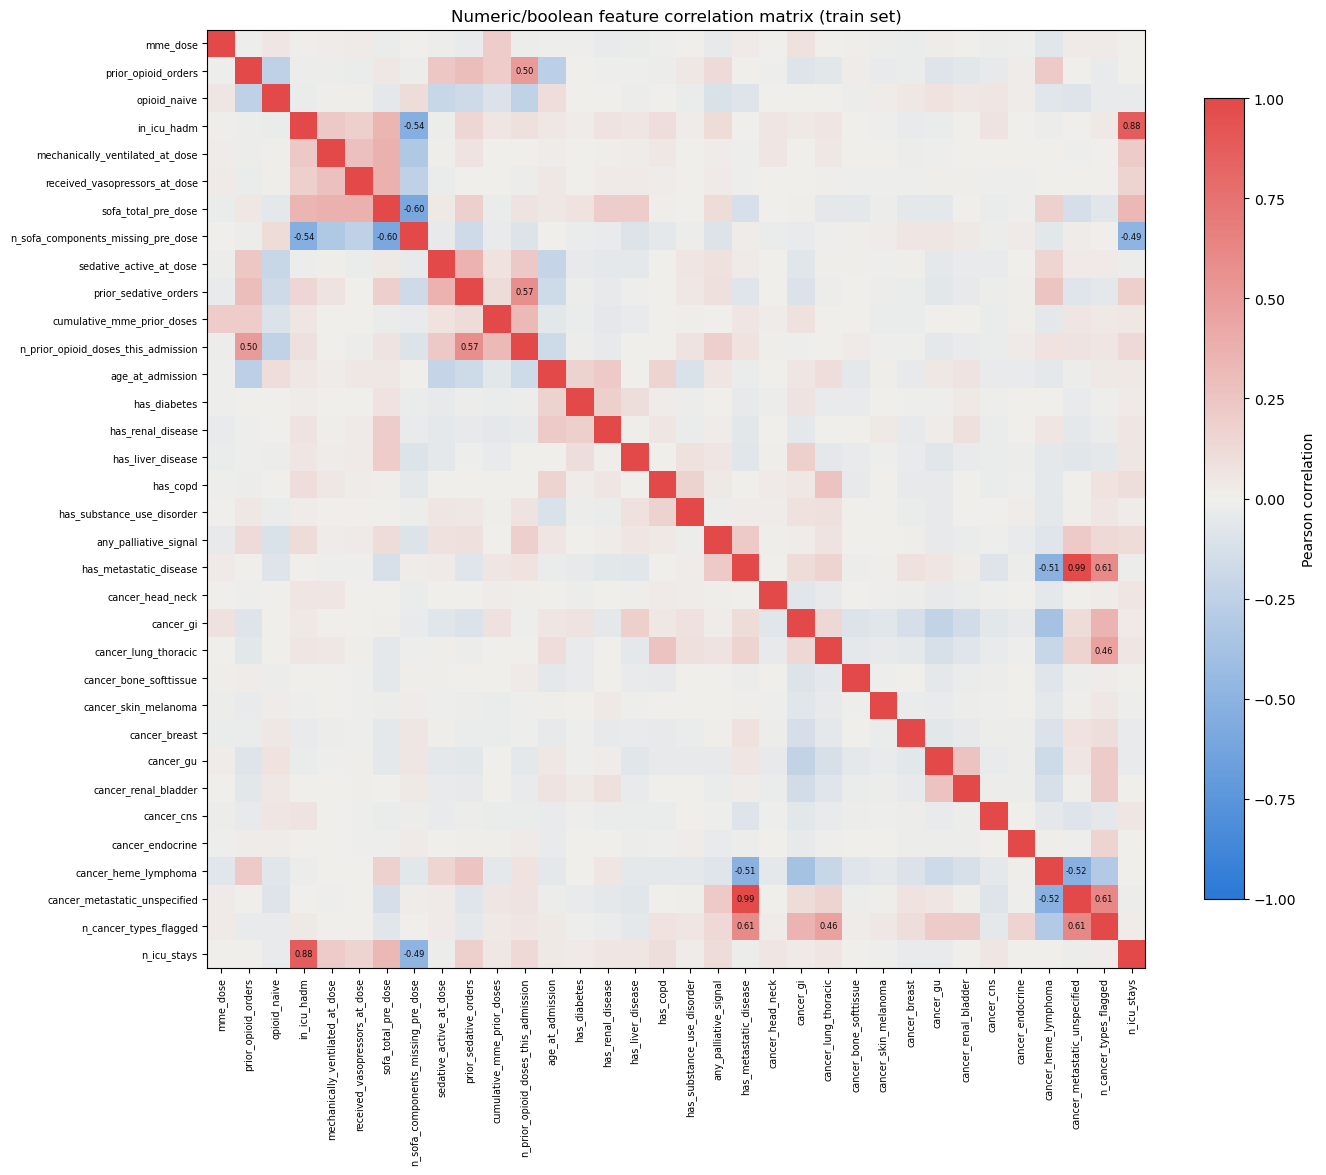

Features most correlated with died_within_48h:
any_palliative_signal                  0.226723
sofa_total_pre_dose                    0.222072
in_icu_hadm                            0.147253
n_icu_stays                            0.120532
n_sofa_components_missing_pre_dose    -0.115101
received_vasopressors_at_dose          0.105980
mechanically_ventilated_at_dose        0.092881
prior_sedative_orders                  0.085412
age_at_admission                       0.069935
n_prior_opioid_doses_this_admission    0.062546

2 feature pairs with |r| > 0.85 (redundancy candidates for the node feature matrix):
  has_metastatic_disease  <->  cancer_metastatic_unspecified   r=0.988
  in_icu_hadm  <->  n_icu_stays   r=0.876


In [20]:
corr_df = X_train[numeric_features].astype(float).copy()
corr_df["__target__"] = y_train.to_numpy()
corr_matrix = corr_df.corr()

feature_corr = corr_matrix.drop(index="__target__", columns="__target__")
target_corr = corr_matrix["__target__"].drop("__target__").sort_values(key=np.abs, ascending=False)

# Diverging blue/gray/red -- blue and red poles read as opposite, gray at 0 reads as "no relationship"
diverging_cmap = LinearSegmentedColormap.from_list("blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"], N=256)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(feature_corr.to_numpy(), cmap=diverging_cmap, vmin=-1, vmax=1)

ax.set_xticks(range(len(feature_corr.columns)))
ax.set_xticklabels(feature_corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(feature_corr.index)))
ax.set_yticklabels(feature_corr.index, fontsize=7)

# Annotate only |r| > 0.4 off-diagonal -- a 36x36 grid is too dense to label every cell
for i in range(feature_corr.shape[0]):
    for j in range(feature_corr.shape[1]):
        r = feature_corr.iat[i, j]
        if i != j and abs(r) > 0.4:
            ax.text(j, i, f"{r:.2f}", ha="center", va="center", fontsize=6, color="#0b0b0b")

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Pearson correlation")
ax.set_title("Numeric/boolean feature correlation matrix (train set)")
plt.tight_layout()
plt.show()

print("Features most correlated with died_within_48h:")
print(target_corr.head(10).to_string())

strong_pairs = [
    (feature_corr.index[i], feature_corr.columns[j], feature_corr.iat[i, j])
    for i in range(feature_corr.shape[0])
    for j in range(i + 1, feature_corr.shape[1])
    if abs(feature_corr.iat[i, j]) > 0.85
]
print(f"\n{len(strong_pairs)} feature pairs with |r| > 0.85 (redundancy candidates for the node feature matrix):")
for a, b, r in sorted(strong_pairs, key=lambda t: -abs(t[2])):
    print(f"  {a}  <->  {b}   r={r:.3f}")

## Building the dose-sequence graph

Two edge types now, not one:

1. **Temporal chain** (as before): each dose connects to the *next* dose in that patient's
   chronological sequence, spanning admissions, `dose_id` tiebreaking exact-timestamp ties.
2. **Same-admission** (new): every pair of doses sharing a `hadm_id` is connected, not just
   chronological neighbors. This directly fixes the low-connectivity problem the chain-only graph
   had (average degree ~1.7, essentially a linear chain) -- doses in the same admission are
   clinically related regardless of exact ordering (same disease episode, same care team), so the
   model should be able to see all of them, not just its immediate chain-neighbor.

Both edge sets carry an **edge weight**: `1.0` for temporal-chain edges, and
`exp(-|delta_t_hours| / TIME_DECAY_HOURS)` for same-admission edges, so doses close together in
time still count more than doses at opposite ends of a long admission. Very large admissions
(more than `ADMISSION_CLIQUE_CAP` doses) skip the full same-admission clique to keep total edge
count bounded -- their doses keep their temporal-chain edges regardless.

As before, every edge only ever connects two doses from the same patient (same-admission doses
share a patient by definition), so no edge can cross the train/test boundary -- reasserted below.


In [21]:
assert dose_df.index.equals(pd.RangeIndex(len(dose_df))), (
    "dose_df's index isn't a plain 0..N-1 range -- the node/edge positions built below assume it is"
)

# ---- Edge set 1: temporal chain, one link per patient to their next dose (spans admissions) ----
node_order = dose_df.sort_values(["subject_id", "starttime", "dose_id"]).index.to_numpy()
sorted_subject_id = dose_df["subject_id"].to_numpy()[node_order]
same_patient_as_next = sorted_subject_id[:-1] == sorted_subject_id[1:]
chain_positions = np.flatnonzero(same_patient_as_next)

chain_src = node_order[chain_positions]
chain_dst = node_order[chain_positions + 1]
chain_weight = np.ones(len(chain_src), dtype=np.float32)

print(f"Temporal-chain edges (directed): {len(chain_src):,}")

# ---- Edge set 2 (new): same-admission, every pair of doses in the same hadm_id ----
# Fixes the low-connectivity problem the chain-only graph had (avg degree ~1.7): doses in the
# same admission are clinically related regardless of exact chronological adjacency. Weighted by
# time proximity so doses close together still count more than ones far apart in a long stay.
TIME_DECAY_HOURS = 24.0
ADMISSION_CLIQUE_CAP = 60  # skip the full clique for pathologically large admissions -- keeps edge count bounded

adm_sorted = dose_df.sort_values(["hadm_id", "starttime", "dose_id"])
adm_positions = adm_sorted.index.to_numpy()
adm_starttime = adm_sorted["starttime"].to_numpy()
adm_group_sizes = adm_sorted.groupby("hadm_id", sort=False).size().to_numpy()

adm_src_parts, adm_dst_parts, adm_w_parts = [], [], []
n_capped = 0
pos = 0
for size in adm_group_sizes:
    if size > 1:
        if size <= ADMISSION_CLIQUE_CAP:
            local_rows, local_cols = np.triu_indices(size, k=1)
            idx = np.arange(pos, pos + size)
            src = adm_positions[idx[local_rows]]
            dst = adm_positions[idx[local_cols]]
            dt_hours = np.abs(adm_starttime[idx[local_rows]] - adm_starttime[idx[local_cols]]) / np.timedelta64(1, "h")
            adm_src_parts.append(src)
            adm_dst_parts.append(dst)
            adm_w_parts.append(np.exp(-dt_hours / TIME_DECAY_HOURS).astype(np.float32))
        else:
            n_capped += 1
    pos += size

adm_src = np.concatenate(adm_src_parts)
adm_dst = np.concatenate(adm_dst_parts)
adm_weight = np.concatenate(adm_w_parts)

print(f"Same-admission edges (directed): {len(adm_src):,} "
      f"({n_capped:,} admissions over the {ADMISSION_CLIQUE_CAP}-dose cap, chain edges still cover those)")

# ---- Combine, mirror for undirected, build the PyG graph ----
src_all = np.concatenate([chain_src, adm_src])
dst_all = np.concatenate([chain_dst, adm_dst])
weight_all = np.concatenate([chain_weight, adm_weight])

edge_index_directed = np.vstack([src_all, dst_all])
edge_index_undirected = np.hstack([edge_index_directed, edge_index_directed[[1, 0], :]])
edge_weight_undirected = np.concatenate([weight_all, weight_all])

avg_degree = edge_index_undirected.shape[1] / len(dose_df)
nodes_with_edges = np.union1d(edge_index_undirected[0], edge_index_undirected[1])
n_isolated_final = len(dose_df) - len(nodes_with_edges)
print(f"\nCombined graph: {len(dose_df):,} nodes, {edge_index_undirected.shape[1]:,} directed edge-endpoints "
      f"(undirected view), avg degree {avg_degree:.2f} (was ~1.7 with the chain-only graph)")
print(f"Nodes with zero edges (single-dose patients, unreachable by either edge set): {n_isolated_final:,}")

# ---- Node features: same leakage-safe rare-category-grouped preprocessing as before ----
X_all_enc = preprocessor_grouped.transform(dose_df[feature_cols])
if hasattr(X_all_enc, "toarray"):
    X_all_enc = X_all_enc.toarray()
y_all = dose_df[TARGET].astype(int).to_numpy()

train_mask = np.zeros(len(dose_df), dtype=bool)
test_mask = np.zeros(len(dose_df), dtype=bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

crossing_edges = train_mask[edge_index_undirected[0]] & test_mask[edge_index_undirected[1]]
assert not crossing_edges.any(), (
    "found an edge crossing the train/test patient boundary -- this would leak test information into training"
)
print("Confirmed: no edges cross the train/test patient boundary.")

graph_data = Data(
    x=torch.tensor(X_all_enc, dtype=torch.float32),
    edge_index=torch.tensor(edge_index_undirected, dtype=torch.long),
    edge_weight=torch.tensor(edge_weight_undirected, dtype=torch.float32),
    y=torch.tensor(y_all, dtype=torch.float32),
    train_mask=torch.tensor(train_mask),
    test_mask=torch.tensor(test_mask),
)
print(graph_data)

Temporal-chain edges (directed): 131,213
Same-admission edges (directed): 599,997 (16 admissions over the 60-dose cap, chain edges still cover those)

Combined graph: 153,232 nodes, 1,462,420 directed edge-endpoints (undirected view), avg degree 9.54 (was ~1.7 with the chain-only graph)
Nodes with zero edges (single-dose patients, unreachable by either edge set): 5,112
Confirmed: no edges cross the train/test patient boundary.
Data(x=[153232, 93], edge_index=[2, 1462420], y=[153232], edge_weight=[1462420], train_mask=[153232], test_mask=[153232])


## Graph visuals

Three views of the graph built above. First, two example admissions drawn as arc diagrams -- nodes
placed by actual elapsed hours since the admission's first dose, the temporal chain drawn as a
gray baseline connecting consecutive doses, and same-admission edges drawn as blue arcs whose
opacity reflects the time-decay weight (closer in time = more opaque, matching the same
`TIME_DECAY_HOURS` used to build the real graph). Picked deterministically: the smaller example is
the first admission (by `hadm_id`) with 4-7 doses that includes at least one `died_within_48h=1`
dose (drawn in red), the larger is the first admission with 14-20 doses under the same rule --
illustrating how the same-admission clique's edge count grows roughly quadratically with admission
size while the temporal chain only ever adds one edge per dose, regardless of admission size.

Second, the degree distribution across the full 153K-node graph (log-scale y, since it's heavily
right-skewed by the handful of long admissions) -- shows how much the same-admission edges reshaped
connectivity from the original chain-only graph's ~1.7 average degree.

Third, an actual node-link diagram (`networkx` spring layout, real nodes and edges rather than a
schematic) of one multi-admission patient's *entire* subgraph -- picked deterministically as the
first patient (by `subject_id`) with 2-4 admissions and 10-40 total doses that includes a
`died_within_48h=1` dose. This is an exact subgraph of `graph_data` (filtered from the same
`chain_src`/`chain_dst`/`adm_src`/`adm_dst` arrays used to build it, not re-derived), and it's the
one view that shows both edge types doing their distinct jobs at once: each admission forms a tight
same-admission cluster, and the temporal-chain edges are the thin bridges connecting one admission's
cluster to the next.


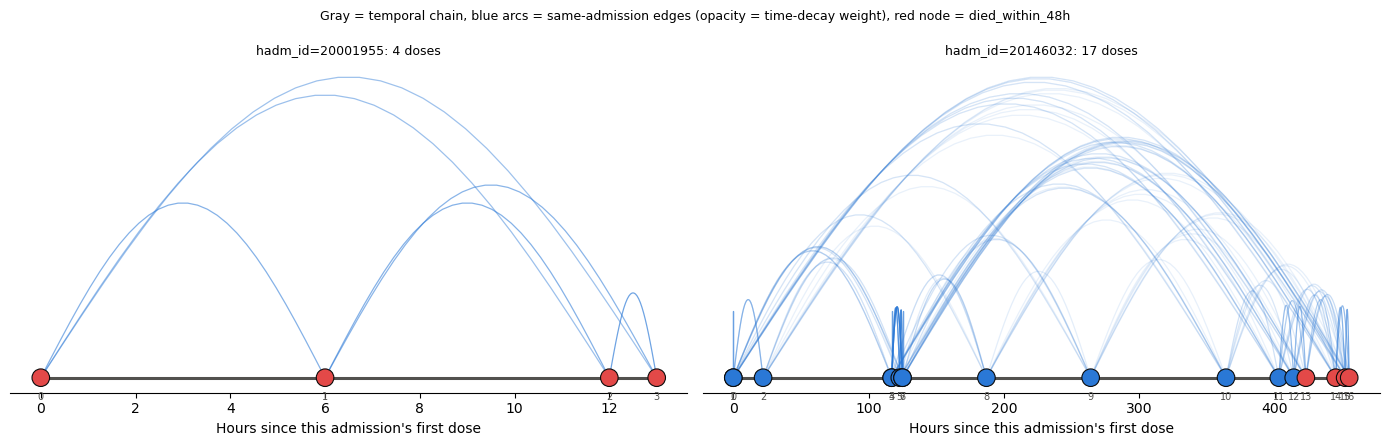

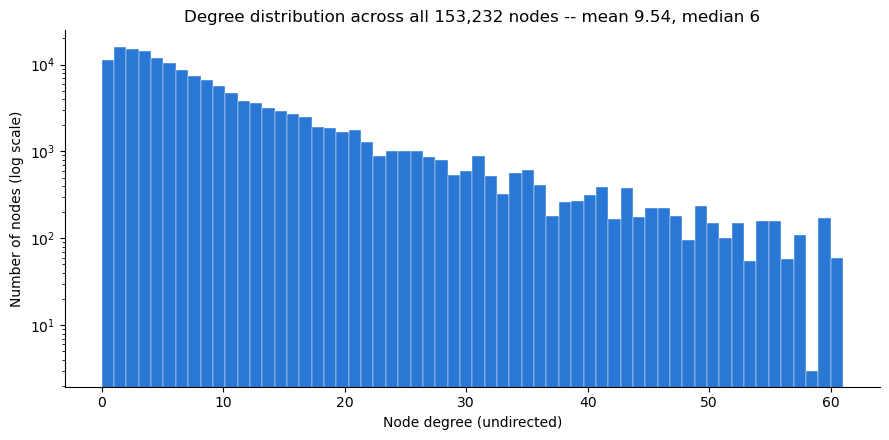

In [22]:
# ---- Two example admissions, drawn as arc diagrams ----
adm_sizes = dose_df.groupby("hadm_id").size()
candidates_small = adm_sizes[(adm_sizes >= 4) & (adm_sizes <= 7)].index
candidates_large = adm_sizes[(adm_sizes >= 14) & (adm_sizes <= 20)].index


def pick_example(candidates):
    """First admission (by hadm_id, for determinism) in the size range that includes a
    died_within_48h=1 dose, so the example is visually informative; falls back to the first
    admission in range if none of them do."""
    for hadm_id in sorted(candidates):
        if dose_df.loc[dose_df["hadm_id"] == hadm_id, "died_within_48h"].any():
            return hadm_id
    return sorted(candidates)[0] if len(candidates) else None


example_small = pick_example(candidates_small)
example_large = pick_example(candidates_large)


def draw_admission_subgraph(hadm_id, ax):
    sub = dose_df[dose_df["hadm_id"] == hadm_id].sort_values(["starttime", "dose_id"]).reset_index(drop=True)
    t0 = sub["starttime"].min()
    x = ((sub["starttime"] - t0) / pd.Timedelta(hours=1)).to_numpy()
    n = len(sub)
    died = sub["died_within_48h"].to_numpy()
    span_total = max(x.max() - x.min(), 1.0)

    # Same-admission edges: arcs above the baseline, opacity = time-decay weight (closer in time = darker)
    for i in range(n):
        for j in range(i + 1, n):
            dt = abs(x[j] - x[i])
            w = np.exp(-dt / TIME_DECAY_HOURS)
            t = np.linspace(0, 1, 30)
            arc_x = x[i] + t * (x[j] - x[i])
            arc_y = np.sin(np.pi * t) * (0.1 + 0.35 * ((x[j] - x[i]) / span_total))
            ax.plot(arc_x, arc_y, color="#2a78d6", alpha=0.1 + 0.6 * w, linewidth=0.9, zorder=1)

    # Temporal-chain edges: gray baseline connecting consecutive doses
    for i in range(n - 1):
        ax.plot([x[i], x[i + 1]], [0, 0], color="#52514e", linewidth=2.2, zorder=2)

    node_colors = ["#e34948" if d else "#2a78d6" for d in died]
    ax.scatter(x, np.zeros(n), s=160, c=node_colors, edgecolors="#0b0b0b", linewidths=0.8, zorder=3)
    for i in range(n):
        ax.annotate(str(i), (x[i], 0), textcoords="offset points", xytext=(0, -16), ha="center", fontsize=7, color="#52514e")

    ax.set_xlabel("Hours since this admission's first dose")
    ax.set_yticks([])
    ax.set_title(f"hadm_id={hadm_id}: {n} doses", fontsize=9)
    for spine in ("top", "left", "right"):
        ax.spines[spine].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
if example_small is not None:
    draw_admission_subgraph(example_small, axes[0])
if example_large is not None:
    draw_admission_subgraph(example_large, axes[1])
fig.suptitle("Gray = temporal chain, blue arcs = same-admission edges (opacity = time-decay weight), red node = died_within_48h", fontsize=9)
plt.tight_layout()
plt.show()

# ---- Full-graph degree distribution ----
node_degree = np.bincount(edge_index_undirected[0], minlength=graph_data.num_nodes)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(node_degree, bins=60, color="#2a78d6", edgecolor="#fcfcfb", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("Node degree (undirected)")
ax.set_ylabel("Number of nodes (log scale)")
ax.set_title(f"Degree distribution across all {graph_data.num_nodes:,} nodes -- mean {node_degree.mean():.2f}, median {np.median(node_degree):.0f}")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

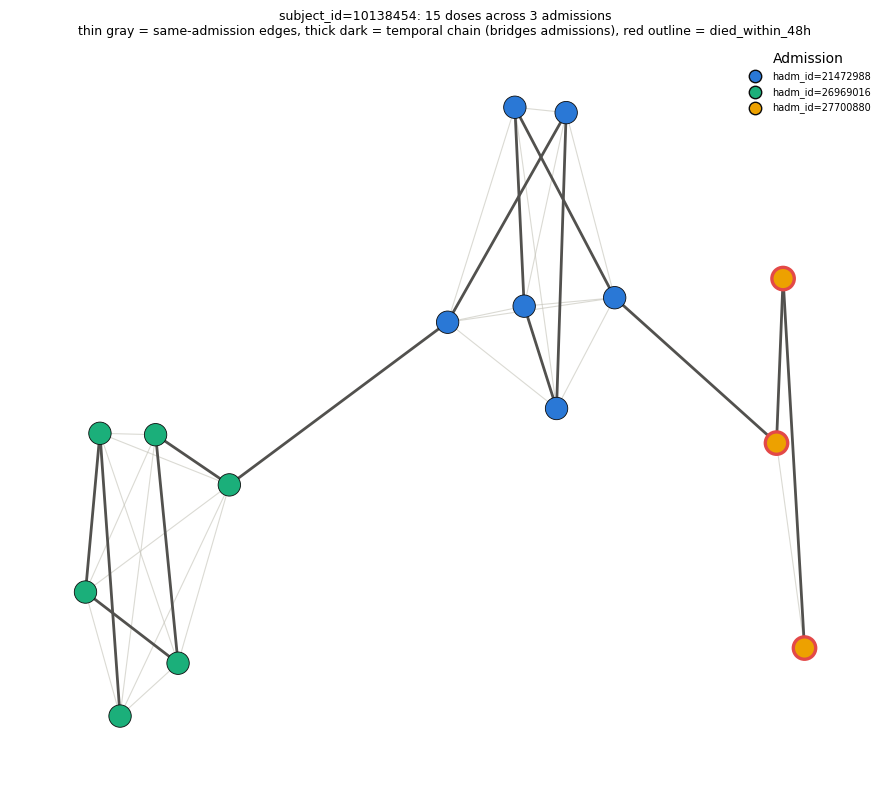

Node-link view of subject_id=10138454's subgraph: 15 nodes, 35 edges (14 chain, 33 same-admission). Each tight cluster is one admission; the thick edge(s) crossing between clusters are the temporal-chain links spanning admissions -- the same construction described in the graph-building section above.


In [23]:
# ---- Node-link view: one multi-admission patient's full subgraph ----
# A single patient with 2-4 admissions is the natural unit to draw this way -- every edge in the
# real graph only ever connects two doses from the same patient, so this is an exact, self-contained
# subgraph of graph_data, not an approximation. It's also the one case guaranteed to show both edge
# types together: dense same-admission clusters bridged by the sparser temporal chain.
n_admissions_per_patient = dose_df.groupby("subject_id")["hadm_id"].nunique()
multi_adm_patients = n_admissions_per_patient[(n_admissions_per_patient >= 2) & (n_admissions_per_patient <= 4)]
patient_dose_counts = dose_df.groupby("subject_id").size()
# Cap doses per admission too, not just total doses -- otherwise the same-admission clique for
# this patient can still collapse into an unreadable hairball once every clique edge is drawn
# (each admission is a fully-connected clique of its own doses).
max_doses_per_admission = dose_df.groupby(["subject_id", "hadm_id"]).size().groupby("subject_id").max()
candidate_patients = [
    s for s in sorted(multi_adm_patients.index)
    if 10 <= patient_dose_counts.get(s, 0) <= 40 and max_doses_per_admission.get(s, 0) <= 8
]


def pick_patient(candidates):
    for s in candidates:
        if dose_df.loc[dose_df["subject_id"] == s, "died_within_48h"].any():
            return s
    return candidates[0] if candidates else None


example_patient = pick_patient(candidate_patients)
patient_node_idx = dose_df.index[dose_df["subject_id"] == example_patient].to_numpy()
patient_node_set = set(patient_node_idx.tolist())

# Reuse the exact edge lists built above (chain_src/chain_dst, adm_src/adm_dst), restricted to this
# patient's nodes -- not a separate re-derivation, so this is guaranteed to match graph_data.
chain_mask_p = np.isin(chain_src, patient_node_idx)
adm_mask_p = np.isin(adm_src, patient_node_idx)
patient_chain_edges = list(zip(chain_src[chain_mask_p].tolist(), chain_dst[chain_mask_p].tolist()))
patient_adm_edges = list(zip(adm_src[adm_mask_p].tolist(), adm_dst[adm_mask_p].tolist()))

G = nx.Graph()
G.add_nodes_from(patient_node_idx.tolist())
G.add_edges_from(patient_adm_edges)
G.add_edges_from(patient_chain_edges)
pos = nx.spring_layout(G, seed=RANDOM_STATE, k=0.6)

admission_ids = sorted(dose_df.loc[list(patient_node_set), "hadm_id"].unique())
admission_palette = ["#2a78d6", "#1baf7a", "#eda100", "#008300"]  # categorical slots 1/2/3/4 -- identity, not magnitude
admission_color_map = dict(zip(admission_ids, admission_palette))

node_face_colors = [admission_color_map[dose_df.loc[n, "hadm_id"]] for n in G.nodes]
node_edge_colors = ["#e34948" if dose_df.loc[n, "died_within_48h"] else "#0b0b0b" for n in G.nodes]
node_edge_widths = [2.4 if dose_df.loc[n, "died_within_48h"] else 0.6 for n in G.nodes]

fig, ax = plt.subplots(figsize=(9, 8))
nx.draw_networkx_edges(G, pos, edgelist=patient_adm_edges, edge_color="#c3c2b7", width=0.8, alpha=0.6, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=patient_chain_edges, edge_color="#52514e", width=2.0, ax=ax)
nx.draw_networkx_nodes(
    G, pos, node_color=node_face_colors, edgecolors=node_edge_colors,
    linewidths=node_edge_widths, node_size=260, ax=ax,
)
for h in admission_ids:
    ax.scatter([], [], color=admission_color_map[h], edgecolors="#0b0b0b", s=80, label=f"hadm_id={h}")
ax.legend(loc="upper right", fontsize=7, frameon=False, title="Admission")
ax.set_title(
    f"subject_id={example_patient}: {G.number_of_nodes()} doses across {len(admission_ids)} admissions\n"
    "thin gray = same-admission edges, thick dark = temporal chain (bridges admissions), "
    "red outline = died_within_48h",
    fontsize=9,
)
ax.axis("off")
plt.tight_layout()
plt.show()

print(
    f"Node-link view of subject_id={example_patient}'s subgraph: {G.number_of_nodes()} nodes, "
    f"{G.number_of_edges()} edges ({len(patient_chain_edges)} chain, {len(patient_adm_edges)} same-admission). "
    "Each tight cluster is one admission; the thick edge(s) crossing between clusters are the "
    "temporal-chain links spanning admissions -- the same construction described in the graph-building section above."
)

## Quick reference baseline: untuned GBM

Not the fully-tuned model from `Intro.ipynb` (that one goes through `RandomizedSearchCV` with a grouped CV) -- just a fast same-notebook reference point so the GNN numbers below have something flat to compare against without re-running that search here.

In [24]:
gbm_pipe = Pipeline([
    ("preprocess", clone(preprocessor_grouped)),
    ("model", HistGradientBoostingClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
])
gbm_pipe.fit(X_train, y_train)
gbm_test_proba = gbm_pipe.predict_proba(X_test)[:, 1]
print(f"Untuned GBM -- ROC-AUC: {roc_auc_score(y_test, gbm_test_proba):.3f}  "
      f"PR-AUC: {average_precision_score(y_test, gbm_test_proba):.3f}")

Untuned GBM -- ROC-AUC: 0.941  PR-AUC: 0.523


## Reference point: Intro.ipynb's tuned GBM

The untuned GBM above is a fast same-notebook stand-in, not the actual bar these GNNs need to clear. `Intro.ipynb` runs the same feature set through a `RandomizedSearchCV`-tuned `HistGradientBoostingClassifier` (grouped CV) and gets ROC-AUC 0.945 / PR-AUC 0.540 -- meaningfully higher PR-AUC than the untuned version's result above. 

In [25]:
# From Intro.ipynb's RandomizedSearchCV-tuned HistGradientBoostingClassifier (grouped CV),
# same feature set. Not reproduced here -- the search itself takes several minutes and is
# orthogonal to the GNN comparisons this notebook is actually about. Refresh these two numbers
# by rerunning Intro.ipynb's tuning cell if the underlying data/features change.
TUNED_GBM_ROC_AUC = 0.945
TUNED_GBM_PR_AUC = 0.540

## Train/validation split, for early stopping

Carve a validation set out of the *training* patients (never the
test set) with a second grouped split, track validation PR-AUC during training, and keep whichever
epoch's weights had the best validation PR-AUC rather than whatever the last epoch produced.


In [26]:
val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
fit_train_pos, val_pos = next(val_splitter.split(X_train, y_train, groups=groups_train))

# fit_train_pos/val_pos are positional within X_train -- map back to positions in dose_df
fit_train_dose_idx = train_idx[fit_train_pos]
val_dose_idx = train_idx[val_pos]

assert set(groups.iloc[fit_train_dose_idx]) & set(groups.iloc[val_dose_idx]) == set()
assert set(groups.iloc[val_dose_idx]) & set(groups.iloc[test_idx]) == set()

fit_train_mask = np.zeros(len(dose_df), dtype=bool)
val_mask = np.zeros(len(dose_df), dtype=bool)
fit_train_mask[fit_train_dose_idx] = True
val_mask[val_dose_idx] = True

graph_data.fit_train_mask = torch.tensor(fit_train_mask)
graph_data.val_mask = torch.tensor(val_mask)

print(f"Fit-train: {fit_train_mask.sum():,} doses  |  Validation: {val_mask.sum():,} doses  |  "
      f"Test: {test_mask.sum():,} doses (unchanged)")

Fit-train: 91,518 doses  |  Validation: 23,356 doses  |  Test: 38,358 doses (unchanged)


## Shared training loop, with early stopping

All three GNNs below (`GraphSAGE`, `GCN`, `GAT`) train with the same procedure, written once
instead of copy-pasted three times: `train_gnn` takes a **model factory** (a zero-arg callable
that constructs a fresh model) rather than an already-built model, and seeds `torch.manual_seed`
*before* calling it -- an earlier version seeded after the model was already constructed, which
meant weight initialization wasn't actually controlled by the seed. This factory pattern is also
what makes the multi-seed robustness check further down possible: it can ask for N independently-
initialized models without copy-pasting the model-construction line N times.

Also: a class-weighted **focal loss** (`FOCAL_GAMMA=2.0`) instead of plain weighted
`BCEWithLogitsLoss` -- same `pos_weight` up-weighting for the ~3.6% positive class, plus a
`(1-p_t)^gamma` term that down-weights examples the model already gets right confidently -- a
`ReduceLROnPlateau` scheduler that halves the learning rate after 3 stale validation checks (15
epochs), giving each model a chance to keep improving before the outer early-stopping patience (8
checks / 40 epochs) gives up, validation PR-AUC checked every few epochs, the
best-validation-PR-AUC weights kept via `copy.deepcopy`, and the final test-set numbers reported
from that best checkpoint rather than the last epoch trained.


In [27]:
MAX_EPOCHS = 300
VAL_EVERY = 5
PATIENCE = 8  # number of validation checks (i.e. PATIENCE * VAL_EVERY epochs) without improvement before stopping
FOCAL_GAMMA = 2.0  # down-weights already-easy examples so training focuses on the hard ~3.6% positive class

n_pos = graph_data.y[graph_data.fit_train_mask].sum().item()
n_neg = graph_data.fit_train_mask.sum().item() - n_pos
pos_weight = torch.tensor(n_neg / n_pos)  # class_weight="balanced" equivalent
y_test_graph = graph_data.y[graph_data.test_mask].numpy()


def focal_loss_with_logits(logits, targets, pos_weight, gamma=FOCAL_GAMMA):
    """Class-weighted focal loss (Lin et al. 2017): same pos_weight up-weighting as
    BCEWithLogitsLoss, plus a (1 - p_t)^gamma term that down-weights examples the model already
    classifies confidently and correctly, so training isn't dominated by the easy majority-class
    negatives at a ~3.6% positive rate."""
    probs = torch.sigmoid(logits)
    p_t = torch.where(targets == 1, probs, 1 - probs)
    alpha_t = torch.where(targets == 1, pos_weight, torch.ones_like(pos_weight))
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    return (alpha_t * (1 - p_t).pow(gamma) * bce).mean()


def loss_fn(logits, targets):
    return focal_loss_with_logits(logits, targets, pos_weight)


GNNResult = namedtuple(
    "GNNResult", ["model", "test_proba", "roc_auc", "pr_auc", "val_pr_auc", "val_proba"]
)


def train_gnn(model_factory, name, use_edge_weight=False, seed=RANDOM_STATE, verbose=True,
              lr=0.01, weight_decay=5e-4):
    """Builds a fresh model from `model_factory` (a zero-arg callable) and trains it with early
    stopping on validation PR-AUC. Seeding happens *before* `model_factory()` is called, not just
    before the training loop -- earlier versions of this cell passed an already-constructed model
    in and seeded afterward, which meant weight initialization was never actually controlled by
    `seed` at all, only dropout/training-time randomness was. That was a real source of run-to-run
    variance between "identical" runs, independent of the scatter-op nondeterminism PyG has on
    CPU. `lr`/`weight_decay` are exposed (not just MAX_EPOCHS/VAL_EVERY/PATIENCE above) so the
    hyperparameter search later in this notebook can vary them too. Returns a `GNNResult`
    (model, test_proba, roc_auc, pr_auc, val_pr_auc, val_proba) -- the val_* fields are the best
    checkpoint's own validation predictions/score, needed so hyperparameter selection and
    post-hoc calibration never have to touch the test set."""
    torch.manual_seed(seed)
    model = model_factory()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # Halves the LR after 3 stale validation checks (15 epochs) -- gives each model a chance to
    # keep improving before the outer early-stopping patience (8 checks / 40 epochs) gives up.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    def forward(mask):
        if use_edge_weight:
            logits = model(graph_data.x, graph_data.edge_index, graph_data.edge_weight)
        else:
            logits = model(graph_data.x, graph_data.edge_index)
        return logits[mask]

    best_val_pr_auc, best_state, best_epoch, stale_checks, best_val_proba = -1.0, None, 0, 0, None

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(forward(graph_data.fit_train_mask), graph_data.y[graph_data.fit_train_mask])
        loss.backward()
        optimizer.step()

        if epoch % VAL_EVERY == 0:
            model.eval()
            with torch.no_grad():
                val_proba = torch.sigmoid(forward(graph_data.val_mask)).numpy()
            val_pr_auc = average_precision_score(graph_data.y[graph_data.val_mask].numpy(), val_proba)
            scheduler.step(val_pr_auc)

            if val_pr_auc > best_val_pr_auc:
                best_val_pr_auc, best_state, best_epoch, stale_checks, best_val_proba = (
                    val_pr_auc, copy.deepcopy(model.state_dict()), epoch, 0, val_proba.copy()
                )
            else:
                stale_checks += 1

            if verbose and epoch % 25 == 0:
                lr_now = optimizer.param_groups[0]["lr"]
                print(f"  [{name}] epoch {epoch:>3}/{MAX_EPOCHS}  train loss {loss.item():.4f}  "
                      f"val PR-AUC {val_pr_auc:.3f}  (best {best_val_pr_auc:.3f} @ epoch {best_epoch})  lr {lr_now:.4f}")

            if stale_checks >= PATIENCE:
                if verbose:
                    print(f"  [{name}] early stop at epoch {epoch} -- no val PR-AUC improvement in "
                          f"{PATIENCE * VAL_EVERY} epochs")
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_proba = torch.sigmoid(forward(graph_data.test_mask)).numpy()

    roc = roc_auc_score(y_test_graph, test_proba)
    pr = average_precision_score(y_test_graph, test_proba)
    if verbose:
        print(f"{name} (best epoch {best_epoch}) -- ROC-AUC: {roc:.3f}  PR-AUC: {pr:.3f}\n")
    return GNNResult(model, test_proba, roc, pr, best_val_pr_auc, best_val_proba)

## No-graph ablation (MLP) -- does the graph structure actually help?

The three GNNs below are being compared against a GBM, which conflates two separate questions:
"does the graph help?" and "is a neural net better than a tree ensemble here?" This model answers
the first question directly: same node features, same depth/dropout/residual/skip-connection
pattern, same `train_gnn` harness (focal loss, LR scheduler, early stopping) -- but plain `Linear`
layers instead of graph convolutions, so it never sees `edge_index` at all. If this scores close to
`GraphSAGE`/`GCN`, the ~600K same-admission edges aren't earning their complexity for this task.


In [28]:
class DoseMLP(torch.nn.Module):
    """No-graph baseline: identical node features, depth, dropout, residual, and skip-connection
    pattern as the three GNNs below, but plain Linear layers instead of graph convolutions --
    edge_index/edge_weight are accepted (train_gnn always passes them) but never used. Isolates
    whether the graph structure itself is adding predictive value, or whether the GNNs' scores are
    coming entirely from the node features a non-graph model would also have access to."""

    def __init__(self, in_channels, hidden_channels=64, dropout=0.3):
        super().__init__()
        self.lin1 = torch.nn.Linear(in_channels, hidden_channels)
        self.lin2 = torch.nn.Linear(hidden_channels, hidden_channels)
        self.lin3 = torch.nn.Linear(hidden_channels, hidden_channels)
        self.dropout = dropout
        self.out = torch.nn.Linear(hidden_channels + in_channels, 1)

    def forward(self, x, edge_index=None, edge_weight=None):
        h = self.lin1(x).relu()
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(h + self.lin2(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(h + self.lin3(h))
        h = torch.cat([h, x], dim=-1)
        return self.out(h).squeeze(-1)


mlp_model, mlp_test_proba, mlp_roc_auc, mlp_pr_auc, mlp_val_pr_auc, mlp_val_proba = train_gnn(
    lambda: DoseMLP(in_channels=graph_data.x.shape[1]), "MLP (no graph)"
)

  [MLP (no graph)] epoch  25/300  train loss 0.1601  val PR-AUC 0.449  (best 0.449 @ epoch 25)  lr 0.0100
  [MLP (no graph)] epoch  50/300  train loss 0.1349  val PR-AUC 0.495  (best 0.499 @ epoch 45)  lr 0.0100
  [MLP (no graph)] epoch  75/300  train loss 0.1140  val PR-AUC 0.499  (best 0.502 @ epoch 65)  lr 0.0100
  [MLP (no graph)] epoch 100/300  train loss 0.1005  val PR-AUC 0.500  (best 0.505 @ epoch 95)  lr 0.0050
  [MLP (no graph)] epoch 125/300  train loss 0.0921  val PR-AUC 0.503  (best 0.506 @ epoch 115)  lr 0.0050
  [MLP (no graph)] epoch 150/300  train loss 0.0881  val PR-AUC 0.500  (best 0.506 @ epoch 115)  lr 0.0025
  [MLP (no graph)] early stop at epoch 155 -- no val PR-AUC improvement in 40 epochs
MLP (no graph) (best epoch 115) -- ROC-AUC: 0.923  PR-AUC: 0.501



## Inductive GNN (GraphSAGE) -- deeper, with a self-feature skip connection and residual conv blocks

Three `SAGEConv` layers instead of two (a node can now aggregate information from up to 3 hops
away -- e.g. an admission-mate's admission-mate), dropout between layers now that both the model
and the graph are richer, a skip connection concatenating each node's own raw features back in
before the final linear layer (so a node with a weak or noisy neighborhood, e.g. an isolated
single-dose patient, doesn't lose its own signal to averaging), and a residual connection around
`conv2`/`conv3` (`h = relu(h + conv(h))`) to fight the oversmoothing that tends to show up once a
GNN gets 3 layers deep. Still inductive -- still the architecture that would generalize to a
genuinely new patient without retraining.


In [29]:
class DoseGraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels)
        self.dropout = dropout
        self.lin = torch.nn.Linear(hidden_channels + in_channels, 1)  # skip connection: raw features + embedding

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(h + self.conv2(h, edge_index))  # residual: conv2 is hidden->hidden, dims match
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(h + self.conv3(h, edge_index))  # residual: conv3 is hidden->hidden, dims match
        h = torch.cat([h, x], dim=-1)
        return self.lin(h).squeeze(-1)  # raw logits


sage_model, sage_test_proba, sage_roc_auc, sage_pr_auc, sage_val_pr_auc, sage_val_proba = train_gnn(
    lambda: DoseGraphSAGE(in_channels=graph_data.x.shape[1]), "GraphSAGE"
)

  [GraphSAGE] epoch  25/300  train loss 0.1690  val PR-AUC 0.329  (best 0.329 @ epoch 25)  lr 0.0100
  [GraphSAGE] epoch  50/300  train loss 0.1232  val PR-AUC 0.495  (best 0.495 @ epoch 50)  lr 0.0100
  [GraphSAGE] epoch  75/300  train loss 0.0911  val PR-AUC 0.529  (best 0.529 @ epoch 75)  lr 0.0100
  [GraphSAGE] epoch 100/300  train loss 0.0723  val PR-AUC 0.513  (best 0.534 @ epoch 85)  lr 0.0100
  [GraphSAGE] epoch 125/300  train loss 0.0640  val PR-AUC 0.529  (best 0.534 @ epoch 85)  lr 0.0025
  [GraphSAGE] early stop at epoch 125 -- no val PR-AUC improvement in 40 epochs
GraphSAGE (best epoch 85) -- ROC-AUC: 0.944  PR-AUC: 0.501



## Transductive GNN (GCN) -- deeper, edge-weighted, with a skip connection and residual conv blocks

Same depth/dropout/skip-connection/residual-connection upgrade as `GraphSAGE`, plus this is the
model that actually uses the same-admission edge weights computed above -- `GCNConv` accepts a
scalar `edge_weight` per edge natively, so doses close together in time within an admission get
aggregated more strongly than ones at opposite ends of a long stay. Still transductive in the same
sense as before: `graph_data` already contains every test node/edge, `fit_train_mask`/`val_mask`/
`test_mask` only gate which nodes' predictions feed the loss/early-stopping/final metric, so this
remains a genuine held-out evaluation.


In [30]:
class DoseGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.3):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.dropout = dropout
        self.lin = torch.nn.Linear(hidden_channels + in_channels, 1)

    def forward(self, x, edge_index, edge_weight=None):
        h = self.conv1(x, edge_index, edge_weight).relu()
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(h + self.conv2(h, edge_index, edge_weight))  # residual, dims match
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(h + self.conv3(h, edge_index, edge_weight))  # residual, dims match
        h = torch.cat([h, x], dim=-1)
        return self.lin(h).squeeze(-1)


gcn_model, gcn_test_proba, gcn_roc_auc, gcn_pr_auc, gcn_val_pr_auc, gcn_val_proba = train_gnn(
    lambda: DoseGCN(in_channels=graph_data.x.shape[1]), "GCN", use_edge_weight=True
)

  [GCN] epoch  25/300  train loss 0.1578  val PR-AUC 0.454  (best 0.454 @ epoch 25)  lr 0.0100
  [GCN] epoch  50/300  train loss 0.1178  val PR-AUC 0.520  (best 0.520 @ epoch 50)  lr 0.0100
  [GCN] epoch  75/300  train loss 0.0889  val PR-AUC 0.510  (best 0.525 @ epoch 60)  lr 0.0100
  [GCN] epoch 100/300  train loss 0.0759  val PR-AUC 0.508  (best 0.525 @ epoch 60)  lr 0.0025
  [GCN] early stop at epoch 100 -- no val PR-AUC improvement in 40 epochs
GCN (best epoch 60) -- ROC-AUC: 0.947  PR-AUC: 0.529



## Graph Attention Network (GAT) -- learned neighbor weighting, now edge-weight-aware

`GATConv` learns how much attention to pay each neighbor instead of using a fixed rule (GCN's
weighted average) or treating every neighbor identically (GraphSAGE's mean). With the richer
same-admission edge set, a node can now have far more neighbors than in the original chain-only
graph (an admission with 20 doses gives every one of those doses 19 same-admission neighbors) --
attention lets the model learn which of those actually matter (e.g. the immediately-preceding dose
vs. one from three days earlier). This previously ran with no access to the time-decay edge weight
at all -- `GCN` could use it, `GAT` couldn't, despite `GAT` being the best-performing model. Fixed
here: each `GATConv` now takes `edge_dim=1` and receives the same-admission time-decay weight as an
edge attribute, so attention is learned *on top of* that signal instead of being blind to it.
Multi-head attention (4 heads) gives it more capacity to learn different kinds of relationships in
parallel, and a residual connection around `conv2` (dims match: `heads * hidden_channels` in and
out) fights oversmoothing the same way as the other two models.


In [31]:
class DoseGAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, heads=4, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout, edge_dim=1)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout, edge_dim=1)
        self.conv3 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=dropout, edge_dim=1)
        self.dropout = dropout
        self.lin = torch.nn.Linear(hidden_channels + in_channels, 1)

    def forward(self, x, edge_index, edge_weight=None):
        edge_attr = edge_weight.unsqueeze(-1) if edge_weight is not None else None
        h = F.elu(self.conv1(x, edge_index, edge_attr))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.elu(h + self.conv2(h, edge_index, edge_attr))  # residual: conv2 is (hidden*heads)->(hidden*heads)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv3(h, edge_index, edge_attr).relu()  # heads=1, concat=False -> dim drops to hidden_channels, no residual
        h = torch.cat([h, x], dim=-1)
        return self.lin(h).squeeze(-1)


gat_model, gat_test_proba, gat_roc_auc, gat_pr_auc, gat_val_pr_auc, gat_val_proba = train_gnn(
    lambda: DoseGAT(in_channels=graph_data.x.shape[1]), "GAT", use_edge_weight=True
)

  [GAT] epoch  25/300  train loss 0.1373  val PR-AUC 0.510  (best 0.510 @ epoch 25)  lr 0.0100
  [GAT] epoch  50/300  train loss 0.1135  val PR-AUC 0.545  (best 0.557 @ epoch 40)  lr 0.0100
  [GAT] epoch  75/300  train loss 0.1046  val PR-AUC 0.557  (best 0.557 @ epoch 40)  lr 0.0050
  [GAT] early stop at epoch 80 -- no val PR-AUC improvement in 40 epochs
GAT (best epoch 40) -- ROC-AUC: 0.957  PR-AUC: 0.543



## GAT attention weights

Which neighbors does the trained GAT model actually lean on? This extracts layer-1 attention (the
layer closest to the raw node features, and the most directly interpretable of the three `GATConv`
layers) via `return_attention_weights=True`, then draws it on the same `subject_id` subgraph from
the "Graph visuals" section above -- line width/opacity now encode the model's learned attention
instead of a fixed style per edge type. This is the concrete payoff of the multi-seed result above:
now that GAT's improvement is confirmed real rather than noise, it is worth showing what the
attention mechanism is actually doing.

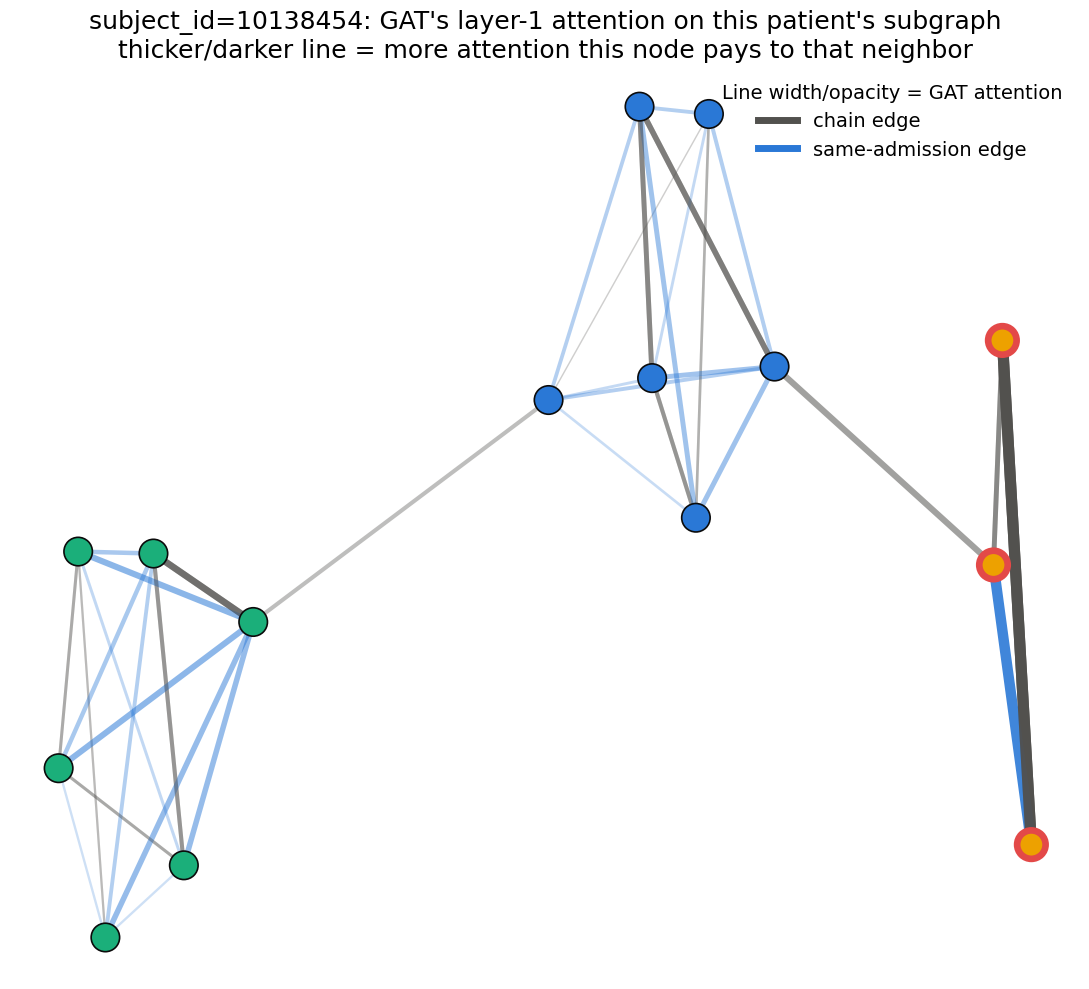

Saved poster figure to /alina-data1/emma-data/poster_figures
Top 5 highest-attention edges in this subgraph:
  dose 118563 <-> dose 118564  (chain)  attention=0.2639
  dose 118563 <-> dose 118564  (chain)  attention=0.2639
  dose 118562 <-> dose 118564  (same-admission)  attention=0.2517
  dose 107397 <-> dose 107398  (chain)  attention=0.1773
  dose 107397 <-> dose 107398  (chain)  attention=0.1773


In [32]:
# ---- Extract GAT's layer-1 attention weights on the full graph ----
# conv1 operates directly on the raw node features, which makes it the most directly interpretable
# of the three GATConv layers -- conv2/conv3 operate on already-mixed hidden representations, one
# more step removed from "which raw neighbor mattered." model.eval() (already set by train_gnn)
# disables GATConv's internal attention dropout, so this is deterministic.
gat_model.eval()
with torch.no_grad():
    edge_attr_full = graph_data.edge_weight.unsqueeze(-1)
    _, (attn_edge_index, attn_alpha) = gat_model.conv1(
        graph_data.x, graph_data.edge_index, edge_attr_full, return_attention_weights=True
    )
attn_alpha_mean = attn_alpha.mean(dim=1)  # average across the 4 attention heads -> one scalar per directed edge

# GATConv adds self-loops internally, so attn_edge_index has more entries than graph_data.edge_index
# -- build a lookup by (source, target) rather than assuming any particular ordering/alignment.
edge_attn_lookup = {
    (s, d): a for s, d, a in zip(attn_edge_index[0].tolist(), attn_edge_index[1].tolist(), attn_alpha_mean.tolist())
}


def edge_attention(u, v):
    """Mean of both directed attention values for the undirected edge (u, v) -- graph_data is
    mirrored/undirected, so each logical edge has two (possibly different) directed attention
    scores; averaging them gives one visual weight per drawn line."""
    vals = [edge_attn_lookup[k] for k in ((u, v), (v, u)) if k in edge_attn_lookup]
    return float(np.mean(vals)) if vals else 0.0


# ---- Draw it on the same subject_id subgraph used in the "Graph visuals" section above ----
patient_all_edges = patient_chain_edges + patient_adm_edges
edge_attn_values = np.array([edge_attention(u, v) for u, v in patient_all_edges])
attn_range = edge_attn_values.max() - edge_attn_values.min()
edge_attn_norm = (edge_attn_values - edge_attn_values.min()) / attn_range if attn_range > 0 else np.zeros_like(edge_attn_values)

# ---- Poster-legible version: bigger fonts/markers, high-res export ----
import os
POSTER_FIG_DIR = "../poster_figures"
os.makedirs(POSTER_FIG_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 10))
for (u, v), norm_w in zip(patient_all_edges, edge_attn_norm):
    is_chain = (u, v) in patient_chain_edges
    ax.plot(
        [pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
        color="#52514e" if is_chain else "#2a78d6",
        linewidth=1.0 + 7.0 * norm_w,
        alpha=0.15 + 0.8 * norm_w,
        zorder=1,
    )
nx.draw_networkx_nodes(
    G, pos, node_color=node_face_colors, edgecolors=node_edge_colors,
    linewidths=[2.0 * w for w in node_edge_widths], node_size=420, ax=ax,
)
ax.plot([], [], color="#52514e", linewidth=5, label="chain edge")
ax.plot([], [], color="#2a78d6", linewidth=5, label="same-admission edge")
ax.legend(loc="upper right", fontsize=14, frameon=False, title="Line width/opacity = GAT attention",
          title_fontsize=14)
ax.set_title(
    f"subject_id={example_patient}: GAT's layer-1 attention on this patient's subgraph\n"
    "thicker/darker line = more attention this node pays to that neighbor",
    fontsize=18,
)
ax.axis("off")
plt.tight_layout()
fig.savefig(os.path.join(POSTER_FIG_DIR, "gat_attention.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(POSTER_FIG_DIR, "gat_attention.pdf"), bbox_inches="tight")
plt.show()
print(f"Saved poster figure to {os.path.abspath(POSTER_FIG_DIR)}")

top_edges = sorted(zip(patient_all_edges, edge_attn_values), key=lambda t: -t[1])[:5]
print("Top 5 highest-attention edges in this subgraph:")
for (u, v), a in top_edges:
    edge_type = "chain" if (u, v) in patient_chain_edges else "same-admission"
    print(f"  dose {u} <-> dose {v}  ({edge_type})  attention={a:.4f}")

## Does GAT's attention rediscover the hand-coded time-decay prior?

The single-patient picture above is illustrative but anecdotal. This is the population-level
companion: it plots every sampled edge's GAT layer-1 attention (already extracted over the full
graph above, not re-derived here) against the time gap between the two doses that edge connects,
split by edge type. GCN's edge weight was hand-coded as a time-decay function -- this checks
whether GAT's *learned* attention rediscovers that same pattern on its own, or relies on
something the hand-coded prior doesn't capture.


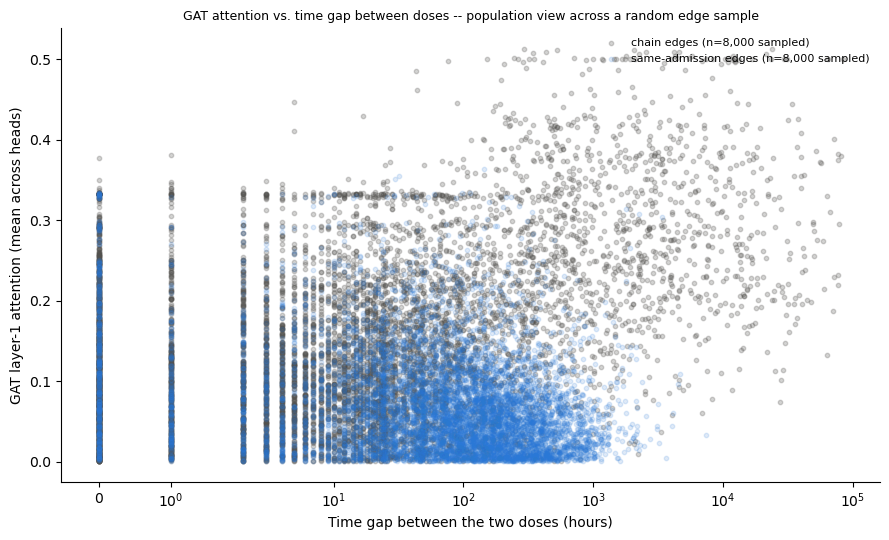

Correlation(attention, time gap): chain edges r=0.241, same-admission edges r=-0.136
Negative r would match the hand-coded time-decay prior (closer in time -> more weight); near-zero or positive would mean GAT learned something the hand-coded GCN edge weight doesn't capture.


In [33]:
# ---- Aggregate view: attention vs. time gap, across a random sample of edges ----
# chain_src/chain_dst and adm_src/adm_dst are the full-graph logical edge lists built during
# graph construction above (one direction per logical edge); edge_attention() and
# edge_attn_lookup come from the full-graph extraction in the cell above -- reused here, not
# recomputed. Same-admission edges number in the millions, so both edge types are randomly
# subsampled to a fixed size for a readable, fast scatter plot.
rng = np.random.default_rng(RANDOM_STATE)
MAX_POINTS_PER_TYPE = 8000
start_times = dose_df["starttime"].to_numpy()


def sample_edges(src, dst):
    n = len(src)
    if n > MAX_POINTS_PER_TYPE:
        sel = rng.choice(n, size=MAX_POINTS_PER_TYPE, replace=False)
        return src[sel], dst[sel]
    return src, dst


def edge_dt_hours(src, dst):
    return np.abs(start_times[dst] - start_times[src]) / np.timedelta64(1, "h")


def edge_attn_batch(src, dst):
    return np.array([edge_attention(int(u), int(v)) for u, v in zip(src, dst)])


chain_src_s, chain_dst_s = sample_edges(chain_src, chain_dst)
adm_src_s, adm_dst_s = sample_edges(adm_src, adm_dst)

chain_dt = edge_dt_hours(chain_src_s, chain_dst_s)
chain_attn = edge_attn_batch(chain_src_s, chain_dst_s)
adm_dt = edge_dt_hours(adm_src_s, adm_dst_s)
adm_attn = edge_attn_batch(adm_src_s, adm_dst_s)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(chain_dt, chain_attn, s=10, alpha=0.25, color="#52514e",
           label=f"chain edges (n={len(chain_dt):,} sampled)")
ax.scatter(adm_dt, adm_attn, s=10, alpha=0.15, color="#2a78d6",
           label=f"same-admission edges (n={len(adm_dt):,} sampled)")
ax.set_xlabel("Time gap between the two doses (hours)")
ax.set_ylabel("GAT layer-1 attention (mean across heads)")
ax.set_xscale("symlog")
ax.set_title(
    "GAT attention vs. time gap between doses -- population view across a random edge sample",
    fontsize=9,
)
ax.legend(loc="upper right", fontsize=8, frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

corr_chain = np.corrcoef(chain_dt, chain_attn)[0, 1] if len(chain_dt) > 1 else float("nan")
corr_adm = np.corrcoef(adm_dt, adm_attn)[0, 1] if len(adm_dt) > 1 else float("nan")
print(f"Correlation(attention, time gap): chain edges r={corr_chain:.3f}, same-admission edges r={corr_adm:.3f}")
print("Negative r would match the hand-coded time-decay prior (closer in time -> more weight); "
      "near-zero or positive would mean GAT learned something the hand-coded GCN edge weight doesn't capture.")


## Comparison

Now with early stopping (each model reports its own best-validation-PR-AUC epoch, not a fixed
epoch count), a richer same-admission-aware graph (avg degree well above the original ~1.7), a
third architecture (`GAT`) that learns its own neighbor weighting, and a no-graph `MLP` ablation
run through the exact same harness -- this comparison separates "does a neural net beat a GBM
here" from "does the graph specifically help," rather than answering only the first question.


In [34]:
print("=" * 70)
print("GNN vs. flat-model baselines on the same test-set doses")
print("=" * 70)
print(f"{'Model':<24}{'ROC-AUC':>12}{'PR-AUC':>12}")
print(f"{'GAT':<24}{gat_roc_auc:>12.3f}{gat_pr_auc:>12.3f}")
print(f"{'GCN':<24}{gcn_roc_auc:>12.3f}{gcn_pr_auc:>12.3f}")
print(f"{'GraphSAGE':<24}{sage_roc_auc:>12.3f}{sage_pr_auc:>12.3f}")
print(f"{'MLP (no graph)':<24}{mlp_roc_auc:>12.3f}{mlp_pr_auc:>12.3f}")
print(f"{'Untuned GBM':<24}{roc_auc_score(y_test, gbm_test_proba):>12.3f}{average_precision_score(y_test, gbm_test_proba):>12.3f}")
print(f"{'Tuned GBM (Intro.ipynb)':<24}{TUNED_GBM_ROC_AUC:>12.3f}{TUNED_GBM_PR_AUC:>12.3f}")
print(
    "\nStill single-seed, single-split numbers -- see the multi-seed robustness check below before "
    "trusting the ranking. The MLP row is the key diagnostic: if it's close to GraphSAGE/GCN, the "
    "graph structure isn't adding much beyond what these node features already give a flat model. "
    "The tuned-GBM row (not built in this notebook -- see the reference-point cell above) is the "
    "real bar to clear, not the untuned strawman."
)

GNN vs. flat-model baselines on the same test-set doses
Model                        ROC-AUC      PR-AUC
GAT                            0.957       0.543
GCN                            0.947       0.529
GraphSAGE                      0.944       0.501
MLP (no graph)                 0.923       0.501
Untuned GBM                    0.941       0.523
Tuned GBM (Intro.ipynb)        0.945       0.540

Still single-seed, single-split numbers -- see the multi-seed robustness check below before trusting the ranking. The MLP row is the key diagnostic: if it's close to GraphSAGE/GCN, the graph structure isn't adding much beyond what these node features already give a flat model. The tuned-GBM row (not built in this notebook -- see the reference-point cell above) is the real bar to clear, not the untuned strawman.


## Multi-seed robustness check

The single-seed comparison above can't distinguish "this architecture is better" from "this run
got lucky". This section retrains `GraphSAGE`/`GCN`/`GAT`/`MLP` (the no-graph ablation) across `N_SEEDS`
different weight-initialization seeds (the train/val/test split itself stays fixed -- only model
init/training varies) and reports mean +/- std per architecture, plus two small-sample 95%
confidence-interval checks on GAT's PR-AUC: whether it's distinguishable from the untuned GBM
baseline, and whether it's distinguishable from the no-graph MLP baseline -- the second check is
the more important one, since it's the one that actually tests whether the graph structure is
earning its complexity. This is only possible now because `train_gnn` takes a model *factory* and
seeds before construction (see the shared training loop section) -- with the original
single-model-instance version, every "seed" run would have reused the same already-initialized
weights.


In [35]:
N_SEEDS = 5
SEEDS = list(range(N_SEEDS))

print(f"Training {4 * N_SEEDS} models ({N_SEEDS} seeds x GraphSAGE/GCN/GAT/MLP) -- roughly {N_SEEDS}x "
      "the runtime of the single-seed run above (MLP is fast; the three GNNs dominate the wait).")


def run_multi_seed(model_factory, name, use_edge_weight=False):
    rows = []
    for seed in SEEDS:
        _, _, roc, pr, _, _ = train_gnn(model_factory, name, use_edge_weight=use_edge_weight, seed=seed, verbose=False)
        rows.append({"model": name, "seed": seed, "roc_auc": roc, "pr_auc": pr})
        print(f"  [{name}] seed {seed}: ROC-AUC {roc:.3f}  PR-AUC {pr:.3f}")
    return rows


multi_seed_rows = []
multi_seed_rows += run_multi_seed(lambda: DoseGraphSAGE(in_channels=graph_data.x.shape[1]), "GraphSAGE")
multi_seed_rows += run_multi_seed(lambda: DoseGCN(in_channels=graph_data.x.shape[1]), "GCN", use_edge_weight=True)
multi_seed_rows += run_multi_seed(lambda: DoseGAT(in_channels=graph_data.x.shape[1]), "GAT", use_edge_weight=True)
multi_seed_rows += run_multi_seed(lambda: DoseMLP(in_channels=graph_data.x.shape[1]), "MLP (no graph)")

# GBM has no seed-controlled randomness worth resampling here (no subsampling; class_weight="balanced"
# with a fixed random_state is effectively deterministic) -- kept as a fixed reference line instead.
gbm_roc = roc_auc_score(y_test, gbm_test_proba)
gbm_pr = average_precision_score(y_test, gbm_test_proba)

multi_seed_df = pd.DataFrame(multi_seed_rows)
summary = multi_seed_df.groupby("model")[["roc_auc", "pr_auc"]].agg(["mean", "std"])
summary.columns = ["_".join(c) for c in summary.columns]
summary = summary.reindex(["GAT", "GCN", "GraphSAGE", "MLP (no graph)"])

print("\n" + "=" * 70)
print(f"Mean +/- std over {N_SEEDS} seeds (data split fixed; only model init/training varies)")
print("=" * 70)
for model_name, row in summary.iterrows():
    print(f"{model_name:<16}  ROC-AUC {row['roc_auc_mean']:.3f} +/- {row['roc_auc_std']:.3f}   "
          f"PR-AUC {row['pr_auc_mean']:.3f} +/- {row['pr_auc_std']:.3f}")
print(f"{'Untuned GBM':<16}  ROC-AUC {gbm_roc:.3f} (fixed)         PR-AUC {gbm_pr:.3f} (fixed)")

# 95% CI on GAT's PR-AUC (small-sample t-interval) -- does it exclude the GBM baseline, or overlap it?
gat_pr_values = multi_seed_df.loc[multi_seed_df["model"] == "GAT", "pr_auc"].to_numpy()
mean_gat_pr = gat_pr_values.mean()
se_gat_pr = gat_pr_values.std(ddof=1) / np.sqrt(len(gat_pr_values))
t_crit = stats.t.ppf(0.975, df=len(gat_pr_values) - 1)
ci_low, ci_high = mean_gat_pr - t_crit * se_gat_pr, mean_gat_pr + t_crit * se_gat_pr
inside = ci_low <= gbm_pr <= ci_high
print(f"\nGAT PR-AUC 95% CI (n={len(gat_pr_values)} seeds): [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Untuned GBM PR-AUC ({gbm_pr:.4f}) falls {'INSIDE' if inside else 'OUTSIDE'} that interval -- "
      f"{'not distinguishable from GAT at this sample size' if inside else 'GAT looks like a real improvement, not just noise'}.")

# Same check, but for the graph-vs-no-graph question: does GAT's CI exclude the MLP ablation's mean?
mlp_pr_values = multi_seed_df.loc[multi_seed_df["model"] == "MLP (no graph)", "pr_auc"].to_numpy()
mean_mlp_pr = mlp_pr_values.mean()
inside_mlp = ci_low <= mean_mlp_pr <= ci_high
print(f"MLP (no graph) mean PR-AUC ({mean_mlp_pr:.4f}) falls {'INSIDE' if inside_mlp else 'OUTSIDE'} GAT's 95% CI -- "
      f"{'the graph is not clearly earning its complexity over the same features with no edges' if inside_mlp else 'the graph structure looks like it is adding real signal beyond the node features alone'}.")

# Same check again, but against the real bar: Intro.ipynb's tuned GBM, not the untuned
# strawman built in this notebook.
inside_tuned = ci_low <= TUNED_GBM_PR_AUC <= ci_high
print(f"Tuned GBM PR-AUC ({TUNED_GBM_PR_AUC:.4f}) falls {'INSIDE' if inside_tuned else 'OUTSIDE'} GAT's 95% CI -- "
      f"{'not distinguishable from GAT at this sample size, even against the tuned model' if inside_tuned else 'GAT looks like a real improvement even over the tuned flat model'}.")

Training 20 models (5 seeds x GraphSAGE/GCN/GAT/MLP) -- roughly 5x the runtime of the single-seed run above (MLP is fast; the three GNNs dominate the wait).


  [GraphSAGE] seed 0: ROC-AUC 0.938  PR-AUC 0.500
  [GraphSAGE] seed 1: ROC-AUC 0.947  PR-AUC 0.495
  [GraphSAGE] seed 2: ROC-AUC 0.940  PR-AUC 0.500
  [GraphSAGE] seed 3: ROC-AUC 0.941  PR-AUC 0.484
  [GraphSAGE] seed 4: ROC-AUC 0.941  PR-AUC 0.499
  [GCN] seed 0: ROC-AUC 0.952  PR-AUC 0.543
  [GCN] seed 1: ROC-AUC 0.949  PR-AUC 0.508
  [GCN] seed 2: ROC-AUC 0.948  PR-AUC 0.524
  [GCN] seed 3: ROC-AUC 0.949  PR-AUC 0.536
  [GCN] seed 4: ROC-AUC 0.950  PR-AUC 0.531
  [GAT] seed 0: ROC-AUC 0.961  PR-AUC 0.553
  [GAT] seed 1: ROC-AUC 0.959  PR-AUC 0.576
  [GAT] seed 2: ROC-AUC 0.959  PR-AUC 0.570
  [GAT] seed 3: ROC-AUC 0.958  PR-AUC 0.558
  [GAT] seed 4: ROC-AUC 0.958  PR-AUC 0.565
  [MLP (no graph)] seed 0: ROC-AUC 0.930  PR-AUC 0.508
  [MLP (no graph)] seed 1: ROC-AUC 0.932  PR-AUC 0.500
  [MLP (no graph)] seed 2: ROC-AUC 0.936  PR-AUC 0.509
  [MLP (no graph)] seed 3: ROC-AUC 0.930  PR-AUC 0.491
  [MLP (no graph)] seed 4: ROC-AUC 0.929  PR-AUC 0.496

Mean +/- std over 5 seeds (data sp

## Calibration: are the probabilities trustworthy, not just well-ranked?

ROC-AUC/PR-AUC only measure ranking -- a model can separate classes well while still outputting probabilities that are systematically too high or too low, which matters if these scores are ever used as an actual risk estimate rather than just a ranking. All three GNNs and the MLP ablation are trained with focal loss, which reweights hard/easy examples specifically to improve ranking and has no reason to preserve calibration as a side effect. This checks Brier score (lower is better) for every model, plus a reliability diagram.

Model                      Brier score   Base rate
GAT                             0.0923       0.037
GCN                             0.0780       0.037
GraphSAGE                       0.0614       0.037
MLP (no graph)                  0.0694       0.037
Untuned GBM                     0.0698       0.037


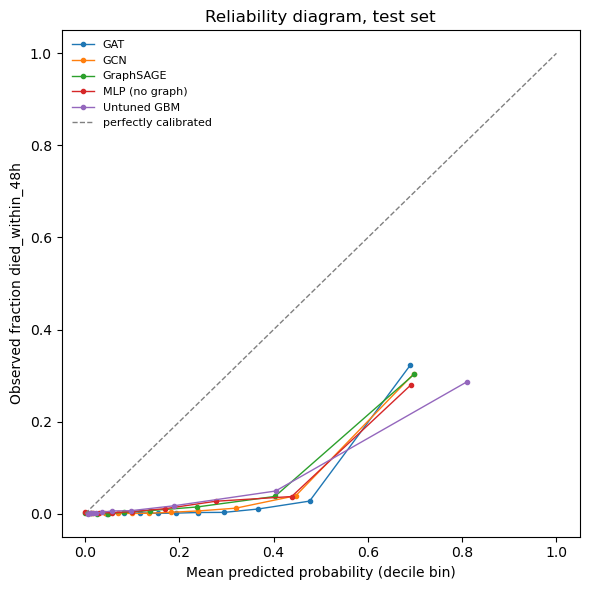

In [36]:
# ---- Brier score (mean squared error of the predicted probability vs. the 0/1 outcome) ----
# Lower is better. Unlike ROC-AUC/PR-AUC, this is sensitive to whether the predicted
# probabilities themselves are trustworthy, not just correctly ordered -- worth checking
# separately since focal loss (used to train all three GNNs + the MLP ablation) optimizes
# ranking, with no guarantee it preserves calibration as a byproduct.
brier_rows = [
    ("GAT", y_test_graph, gat_test_proba),
    ("GCN", y_test_graph, gcn_test_proba),
    ("GraphSAGE", y_test_graph, sage_test_proba),
    ("MLP (no graph)", y_test_graph, mlp_test_proba),
    ("Untuned GBM", y_test.to_numpy(), gbm_test_proba),
]

print(f"{'Model':<24}{'Brier score':>14}{'Base rate':>12}")
for name, y_true, proba in brier_rows:
    print(f"{name:<24}{brier_score_loss(y_true, proba):>14.4f}{y_true.mean():>12.3f}")

# ---- Reliability diagram: predicted probability vs. observed frequency, in deciles ----
fig, ax = plt.subplots(figsize=(6, 6))
for name, y_true, proba in brier_rows:
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", markersize=3, linewidth=1, label=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability (decile bin)")
ax.set_ylabel("Observed fraction died_within_48h")
ax.set_title("Reliability diagram, test set")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Breakdown by opioid_type

We ask specifically whether opioid *type*, not just dose, predicts 48-hour mortality -- an aggregate PR-AUC across all doses doesn't answer that. This reports GAT's and the (untuned) GBM's discrimination separately per `opioid_type` on the test set -- the tuned GBM's row-level predictions aren't reproduced in this notebook, so it isn't part of this breakdown, only its aggregate numbers are, above. Several of these opioids are rare enough in this cohort that a subgroup PR-AUC would be noise, not signal; those are flagged rather than reported.

In [37]:
# ---- Per-opioid_type test-set support ----
# GBM's test predictions (gbm_test_proba) are in X_test/test_idx order; the GNNs' test
# predictions (e.g. gat_test_proba) are in graph_data.test_mask's ascending boolean-index
# order -- these are NOT the same order (see the earlier note on y_test vs. y_test_graph
# alignment), so each needs its own opioid_type array pulled in the matching order rather
# than sharing one.
opioid_type_gbm_order = X_test["opioid_type"].to_numpy()
opioid_type_gnn_order = dose_df["opioid_type"].to_numpy()[graph_data.test_mask.numpy()]

MIN_SUBGROUP_DEATHS = 5  # below this, PR-AUC is too noisy on this few deaths to report

print(f"{'opioid_type':<16}{'n_doses':>9}{'n_deaths':>9}{'GAT ROC-AUC':>13}{'GAT PR-AUC':>12}{'GBM ROC-AUC':>13}{'GBM PR-AUC':>12}")
for opioid in sorted(dose_df["opioid_type"].unique()):
    gnn_sub = opioid_type_gnn_order == opioid
    gbm_sub = opioid_type_gbm_order == opioid
    n_doses = gnn_sub.sum()
    n_deaths = int(y_test_graph[gnn_sub].sum())
    if n_deaths < MIN_SUBGROUP_DEATHS:
        print(f"{opioid:<16}{n_doses:>9,}{n_deaths:>9}  -- < {MIN_SUBGROUP_DEATHS} deaths, PR-AUC too noisy to report")
        continue
    gat_roc_sub = roc_auc_score(y_test_graph[gnn_sub], gat_test_proba[gnn_sub])
    gat_pr_sub = average_precision_score(y_test_graph[gnn_sub], gat_test_proba[gnn_sub])
    gbm_roc_sub = roc_auc_score(y_test.to_numpy()[gbm_sub], gbm_test_proba[gbm_sub])
    gbm_pr_sub = average_precision_score(y_test.to_numpy()[gbm_sub], gbm_test_proba[gbm_sub])
    print(f"{opioid:<16}{n_doses:>9,}{n_deaths:>9}{gat_roc_sub:>13.3f}{gat_pr_sub:>12.3f}"
          f"{gbm_roc_sub:>13.3f}{gbm_pr_sub:>12.3f}")

opioid_type       n_doses n_deaths  GAT ROC-AUC  GAT PR-AUC  GBM ROC-AUC  GBM PR-AUC
buprenorphine          36        0  -- < 5 deaths, PR-AUC too noisy to report
codeine               194        2  -- < 5 deaths, PR-AUC too noisy to report
fentanyl            1,664       50        0.912       0.319        0.874       0.185
hydrocodone           160        0  -- < 5 deaths, PR-AUC too noisy to report
hydromorphone      12,787      530        0.962       0.483        0.936       0.441
methadone             821       20        0.946       0.403        0.936       0.297
morphine            7,321      701        0.945       0.650        0.935       0.649
oxycodone          13,552      113        0.921       0.127        0.882       0.064
tramadol            1,823        6        0.668       0.080        0.724       0.095


## Feature importance heatmap (permutation importance, across all models)

`HistGradientBoostingClassifier` has no built-in `feature_importances_` (unlike tree-ensemble classifiers), and the GNNs/MLP have no importance attribute at all -- so permutation importance (how much test-set PR-AUC drops when one raw feature's values are shuffled) is used uniformly across all five models. It's computed at the *raw*, pre-one-hot-encoding feature level (i.e. one row per entry in `feature_cols`, not per one-hot dummy) so GBM and the four graph-family models land on the same row index and are directly comparable in one heatmap.

**Key correctness point this reuses**: the graph-construction assertion earlier already confirmed no edge ever crosses the train/test boundary, which means a test node's neighbors are always other test nodes. That makes it safe to build a test-only subgraph once (~1/4 the size of the full graph) and reuse it for every permuted forward pass below, instead of re-transforming and re-running inference on the full 153K-node graph each time -- a sanity check right after building it confirms this subgraph reproduces each model's already-recorded PR-AUC exactly before trusting anything computed on it.

Cheaper than the multi-seed cell above (no training, just forward passes), but still does `n_features x (1 + N_REPEATS x 4)` forward/predict calls, so expect a few minutes.

Subgraph equivalence check passed for all four GNN-family models -- safe to reuse for permutation importance.
Computed permutation importance for 40 raw features x 5 models.

Caveat: 2 feature pair(s) flagged as highly correlated (|r| > 0.85) by the correlation heatmap above appear in this table -- each one's individual importance below is likely an underestimate, since the model can lean on its correlated partner when either is shuffled alone. Read these as a joint signal, not two independent ones:
  in_icu_hadm + n_icu_stays  (r=0.876)  -- individual mean importances 0.0238 / -0.0016, combined 0.0222
  has_metastatic_disease + cancer_metastatic_unspecified  (r=0.988)  -- individual mean importances 0.0011 / 0.0018, combined 0.0029


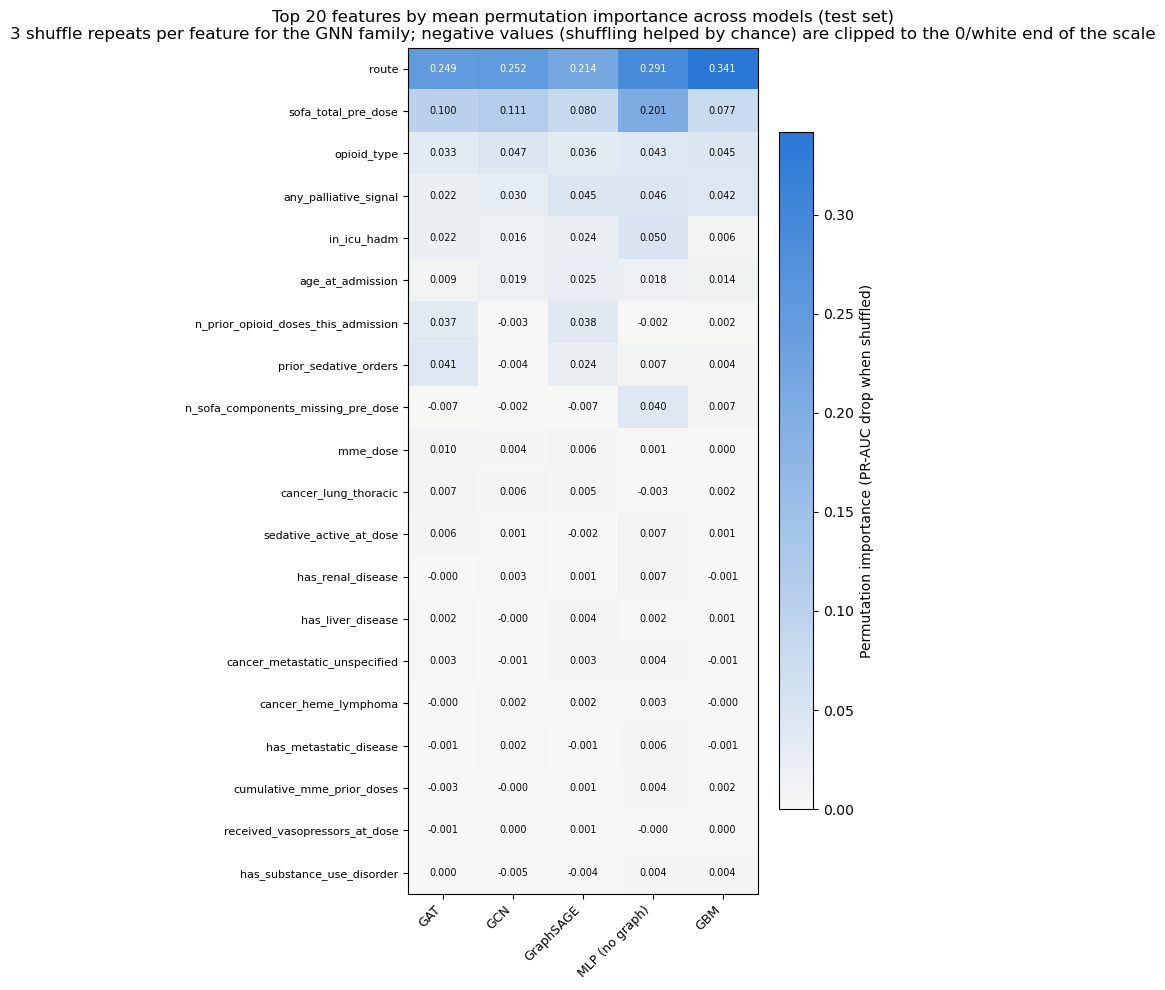

Full importance table, all features, sorted by mean importance across models:
                                        GAT     GCN  GraphSAGE  MLP (no graph)     GBM  mean_importance
feature                                                                                                
route                                0.2485  0.2519     0.2137          0.2912  0.3415           0.2693
sofa_total_pre_dose                  0.1005  0.1115     0.0797          0.2011  0.0775           0.1140
opioid_type                          0.0327  0.0465     0.0356          0.0432  0.0453           0.0407
any_palliative_signal                0.0222  0.0302     0.0446          0.0464  0.0416           0.0370
in_icu_hadm                          0.0219  0.0165     0.0240          0.0505  0.0060           0.0238
age_at_admission                     0.0087  0.0187     0.0254          0.0178  0.0141           0.0169
n_prior_opioid_doses_this_admission  0.0370 -0.0028     0.0385         -0.0017  0.0024    

In [38]:
# ---- Build a test-only subgraph -- see the markdown above for why this is exact, not an ----
# ---- approximation, given no edge crosses the train/test boundary. ----
test_node_ids = np.flatnonzero(graph_data.test_mask.numpy())
local_index = -np.ones(len(dose_df), dtype=np.int64)
local_index[test_node_ids] = np.arange(len(test_node_ids))

edge_src, edge_dst = graph_data.edge_index.numpy()
edge_w_full = graph_data.edge_weight.numpy()
test_mask_np = graph_data.test_mask.numpy()
test_edge_mask = test_mask_np[edge_src] & test_mask_np[edge_dst]

sub_edge_index = torch.tensor(
    np.vstack([local_index[edge_src[test_edge_mask]], local_index[edge_dst[test_edge_mask]]]),
    dtype=torch.long,
)
sub_edge_weight = torch.tensor(edge_w_full[test_edge_mask], dtype=torch.float32)


def sub_forward_pr_auc(model, use_edge_weight, x_enc):
    x_t = torch.tensor(x_enc, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        if use_edge_weight:
            logits = model(x_t, sub_edge_index, sub_edge_weight)
        else:
            logits = model(x_t, sub_edge_index)
        proba = torch.sigmoid(logits).numpy()
    return average_precision_score(y_test_graph, proba)


gnn_models = {
    "GAT": (gat_model, True),
    "GCN": (gcn_model, True),
    "GraphSAGE": (sage_model, False),
    "MLP (no graph)": (mlp_model, False),
}
baseline_pr = {
    "GAT": gat_pr_auc, "GCN": gcn_pr_auc, "GraphSAGE": sage_pr_auc, "MLP (no graph)": mlp_pr_auc,
}

X_test_raw = dose_df.loc[test_node_ids, feature_cols].copy()
X_test_enc_baseline = preprocessor_grouped.transform(X_test_raw)
if hasattr(X_test_enc_baseline, "toarray"):
    X_test_enc_baseline = X_test_enc_baseline.toarray()

for name, (model, use_ew) in gnn_models.items():
    check = sub_forward_pr_auc(model, use_ew, X_test_enc_baseline)
    assert abs(check - baseline_pr[name]) < 1e-6, (
        f"{name} subgraph baseline ({check:.6f}) doesn't match its recorded PR-AUC "
        f"({baseline_pr[name]:.6f}) -- the test-only subgraph isn't equivalent, don't trust "
        f"the permutation importances below until this is fixed"
    )
print("Subgraph equivalence check passed for all four GNN-family models -- safe to reuse for permutation importance.")

baseline_pr["GBM"] = average_precision_score(y_test, gbm_test_proba)

# ---- Permutation importance per raw feature, per model ----
# Shuffling (not zeroing/dropping) a column breaks its relationship with the target while
# preserving its marginal distribution -- the standard permutation-importance definition.
# Averaged over N_REPEATS shuffles per feature for the GNN family since a single shuffle can be
# noisy; GBM is kept to a single shuffle since sklearn's own permutation_importance guidance
# treats tree-ensemble predictions as cheap/stable enough that this matters less there.
N_REPEATS = 3
rng = np.random.default_rng(RANDOM_STATE)

importance_rows = []
for feature in feature_cols:
    X_test_gbm_perm = X_test.copy()
    X_test_gbm_perm[feature] = rng.permutation(X_test_gbm_perm[feature].to_numpy())
    gbm_pr_perm = average_precision_score(y_test, gbm_pipe.predict_proba(X_test_gbm_perm)[:, 1])
    row = {"feature": feature, "GBM": baseline_pr["GBM"] - gbm_pr_perm}

    drops = {name: [] for name in gnn_models}
    for _ in range(N_REPEATS):
        X_test_raw_perm = X_test_raw.copy()
        X_test_raw_perm[feature] = rng.permutation(X_test_raw_perm[feature].to_numpy())
        X_enc_perm = preprocessor_grouped.transform(X_test_raw_perm)
        if hasattr(X_enc_perm, "toarray"):
            X_enc_perm = X_enc_perm.toarray()
        for name, (model, use_ew) in gnn_models.items():
            drops[name].append(baseline_pr[name] - sub_forward_pr_auc(model, use_ew, X_enc_perm))

    for name in gnn_models:
        row[name] = float(np.mean(drops[name]))
    importance_rows.append(row)

importance_df = pd.DataFrame(importance_rows).set_index("feature")
model_order = ["GAT", "GCN", "GraphSAGE", "MLP (no graph)", "GBM"]
importance_df = importance_df[model_order]
importance_df["mean_importance"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("mean_importance", ascending=False)

print(f"Computed permutation importance for {len(importance_df)} raw features x {len(model_order)} models.")

# ---- Caveat: correlated raw features split/dilute each other's individual importance ----
# Permuting one half of a highly-correlated pair barely hurts a model that can lean on the
# other half -- reusing `strong_pairs` from the correlation-heatmap cell above (computed once,
# still live in the kernel) so this stays correct if the underlying data/correlations change,
# rather than hardcoding today's two pairs.
flagged_in_importance = [
    (a, b, r) for a, b, r in strong_pairs
    if a in importance_df.index and b in importance_df.index
]
if flagged_in_importance:
    print(
        f"\nCaveat: {len(flagged_in_importance)} feature pair(s) flagged as highly correlated "
        "(|r| > 0.85) by the correlation heatmap above appear in this table -- each one's "
        "individual importance below is likely an underestimate, since the model can lean on "
        "its correlated partner when either is shuffled alone. Read these as a joint signal, "
        "not two independent ones:"
    )
    for a, b, r in flagged_in_importance:
        combined = importance_df.loc[a, "mean_importance"] + importance_df.loc[b, "mean_importance"]
        print(
            f"  {a} + {b}  (r={r:.3f})  -- individual mean importances "
            f"{importance_df.loc[a, 'mean_importance']:.4f} / {importance_df.loc[b, 'mean_importance']:.4f}, "
            f"combined {combined:.4f}"
        )

# ---- Heatmap: top features by mean importance across all 5 models ----
top_n = min(20, len(importance_df))
plot_df = importance_df.head(top_n).drop(columns="mean_importance")

# Sequential: magnitude only (permutation importance is "how much does removing this feature
# hurt", not a polarity) -- one hue, light to dark, the same blue accent used elsewhere in this
# notebook (e.g. the same-admission edges in the graph visuals).
sequential_cmap = LinearSegmentedColormap.from_list("importance_blue", ["#f7f7f5", "#2a78d6"], N=256)
vmax = max(plot_df.to_numpy().max(), 1e-6)

fig, ax = plt.subplots(figsize=(7, 0.4 * top_n + 2))
im = ax.imshow(plot_df.to_numpy(), cmap=sequential_cmap, vmin=0, vmax=vmax, aspect="auto")

ax.set_xticks(range(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(plot_df.index, fontsize=8)

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        v = plot_df.iat[i, j]
        text_color = "white" if v > vmax * 0.6 else "#0b0b0b"
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7, color=text_color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Permutation importance (PR-AUC drop when shuffled)")
ax.set_title(
    f"Top {top_n} features by mean permutation importance across models (test set)\n"
    f"{N_REPEATS} shuffle repeats per feature for the GNN family; negative values (shuffling helped by "
    "chance) are clipped to the 0/white end of the scale"
)
plt.tight_layout()
plt.show()

print("Full importance table, all features, sorted by mean importance across models:")
print(importance_df.round(4).to_string())

## GAT hyperparameter tuning + calibration

The multi-seed check above confirmed GAT's ranking advantage over the tuned GBM, the untuned GBM, and the no-graph MLP ablation is real, not noise -- so tuning it further is no longer premature. But the calibration check earlier found GAT has the *worst* Brier score of all five models (0.092, actually worse than the trivial always-predict-the-base-rate baseline of ~0.036) despite having the best ranking -- almost certainly the focal loss sharpening its probabilities to help ranking at calibration's expense. Tuning purely for PR-AUC risks making that tradeoff worse, so this bundles both: a random search over GAT's hyperparameters selected by a **combined validation PR-AUC + Brier score**, not PR-AUC alone, followed by **post-hoc isotonic calibration** fit on the validation set (never the test set) and applied to the winning model's test predictions.

Scoped to GAT only, not all four architectures -- it's the one that earned tuning and the one with the calibration problem worth fixing. Each candidate is averaged over 2 seeds (not the full 5 the multi-seed check above used, but enough to stop the search from just picking the luckiest initialization) -- 12 candidates x 2 seeds = 24 `train_gnn` runs, comparable in total cost to the multi-seed cell above.

### Faster training for the search: partition-local subgraphs + checkpointing

Two problems surfaced from the last run: (1) every epoch of every training call runs a forward pass over the *entire* 153K-node/1.46M-edge graph just to compute the fit_train loss (~92K nodes) or, every `VAL_EVERY` epochs, the validation metric (~23K nodes) -- wasted compute on partitions that step doesn't need. (2) the connection dropped mid-search and all progress was lost, because nothing was written to disk until the whole loop finished.

Fix for (1): the same exactness argument already used for the test-only subgraph in the feature-importance section applies here too -- patients never span partitions and every edge is intra-patient, so fit_train nodes' neighbors are always other fit_train nodes (never val/test), and the same holds for val. Restricting message passing to each partition's own subgraph is mathematically identical to running the full graph and masking, just far cheaper. `train_gnn_fast` below is a leaner version of `train_gnn` built on these subgraphs, used only in this section -- the original `train_gnn` and every cell that already ran successfully above are untouched, so nothing already-validated is at risk from this change.

Fix for (2): the search loop (next cell) now writes each completed candidate to a checkpoint CSV immediately and skips any candidate already found there on a rerun -- a dropped connection now costs at most one candidate's worth of time, not the whole search.

In [39]:
# ---- Partition-local subgraphs, built once and reused by every search/refit run below ----
def build_subgraph(mask):
    node_ids = np.flatnonzero(mask.numpy())
    local_index = -np.ones(len(dose_df), dtype=np.int64)
    local_index[node_ids] = np.arange(len(node_ids))
    src, dst = graph_data.edge_index.numpy()
    w = graph_data.edge_weight.numpy()
    mask_np = mask.numpy()
    edge_mask = mask_np[src] & mask_np[dst]
    sub_ei = torch.tensor(
        np.vstack([local_index[src[edge_mask]], local_index[dst[edge_mask]]]), dtype=torch.long
    )
    sub_ew = torch.tensor(w[edge_mask], dtype=torch.float32)
    return graph_data.x[node_ids], sub_ei, sub_ew, graph_data.y[node_ids]


fit_x, fit_ei, fit_ew, fit_y = build_subgraph(graph_data.fit_train_mask)
valsub_x, valsub_ei, valsub_ew, valsub_y = build_subgraph(graph_data.val_mask)

print(f"fit_train subgraph: {fit_x.shape[0]:,} nodes, {fit_ei.shape[1]:,} directed edges "
      f"(full graph: {graph_data.x.shape[0]:,} nodes, {graph_data.edge_index.shape[1]:,} edges)")
print(f"val subgraph: {valsub_x.shape[0]:,} nodes, {valsub_ei.shape[1]:,} directed edges")

# ---- Equivalence check: does the val subgraph reproduce the already-trained GAT's own
# recorded validation PR-AUC (gat_val_pr_auc, from the original full-graph run above)? Same
# discipline as the test-only subgraph check earlier -- if this doesn't match, don't trust
# anything trained on these subgraphs below.
gat_model.eval()
with torch.no_grad():
    check_logits = gat_model(valsub_x, valsub_ei, valsub_ew)
    check_val_pr_auc = average_precision_score(valsub_y.numpy(), torch.sigmoid(check_logits).numpy())
assert abs(check_val_pr_auc - gat_val_pr_auc) < 1e-6, (
    f"val subgraph check failed: got {check_val_pr_auc:.6f}, expected {gat_val_pr_auc:.6f} -- "
    "don't trust train_gnn_fast below until this is fixed"
)
print(f"Val-subgraph equivalence check passed ({check_val_pr_auc:.6f} matches the recorded value).")


FastResult = namedtuple("FastResult", ["model", "val_pr_auc", "val_proba"])


def train_gnn_fast(model_factory, name, use_edge_weight=False, seed=RANDOM_STATE, verbose=False,
                    lr=0.01, weight_decay=5e-4, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    """Same training logic as `train_gnn` (focal loss, early stopping on validation PR-AUC,
    LR-on-plateau scheduling) but trains and validates on the partition-local subgraphs built
    above instead of the full graph -- mathematically identical results (see the equivalence
    check above), just without paying for train/val/test nodes a given step doesn't need. This
    intentionally duplicates train_gnn's loop rather than modifying it in place, so the cells
    above that already ran successfully (and were already reported to the user) stay untouched.
    Doesn't compute test metrics at all -- this function is only used for search/refit, where
    test predictions are read off the existing test-only subgraph instead (see the final refit
    cell below). `max_epochs`/`patience` are separately overridable from the notebook-wide
    MAX_EPOCHS/PATIENCE so the search can use a shorter budget while the final refit still gets
    the full one."""
    torch.manual_seed(seed)
    model = model_factory()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    def fit_logits():
        return model(fit_x, fit_ei, fit_ew) if use_edge_weight else model(fit_x, fit_ei)

    def val_logits():
        return model(valsub_x, valsub_ei, valsub_ew) if use_edge_weight else model(valsub_x, valsub_ei)

    best_val_pr_auc, best_state, best_epoch, stale_checks, best_val_proba = -1.0, None, 0, 0, None

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(fit_logits(), fit_y)
        loss.backward()
        optimizer.step()

        if epoch % VAL_EVERY == 0:
            model.eval()
            with torch.no_grad():
                val_proba = torch.sigmoid(val_logits()).numpy()
            val_pr_auc = average_precision_score(valsub_y.numpy(), val_proba)
            scheduler.step(val_pr_auc)

            if val_pr_auc > best_val_pr_auc:
                best_val_pr_auc, best_state, best_epoch, stale_checks, best_val_proba = (
                    val_pr_auc, copy.deepcopy(model.state_dict()), epoch, 0, val_proba.copy()
                )
            else:
                stale_checks += 1

            if verbose and epoch % 25 == 0:
                print(f"  [{name}] epoch {epoch:>3}/{max_epochs}  val PR-AUC {val_pr_auc:.3f}  "
                      f"(best {best_val_pr_auc:.3f} @ epoch {best_epoch})")

            if stale_checks >= patience:
                if verbose:
                    print(f"  [{name}] early stop at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    model.eval()
    return FastResult(model, best_val_pr_auc, best_val_proba)

fit_train subgraph: 91,518 nodes, 876,136 directed edges (full graph: 153,232 nodes, 1,462,420 edges)
val subgraph: 23,356 nodes, 222,938 directed edges
Val-subgraph equivalence check passed (0.556847 matches the recorded value).


In [40]:
# ---- Random search over GAT hyperparameters, selected on validation PR-AUC + Brier score ----
# Selection uses the val subgraph only -- the test set is never touched until the single
# final evaluation of the winning config in the next cell, same held-out discipline as the
# rest of this notebook. Trains via train_gnn_fast (partition-local subgraphs, see above) and
# checkpoints every completed candidate to disk so a dropped connection costs at most one
# candidate, not the whole search.
GAT_SEARCH_SPACE = {
    "hidden_channels": [32, 64, 96],
    "heads": [2, 4, 8],
    "dropout": [0.2, 0.3, 0.4],
    "lr": [0.005, 0.01, 0.02],
    "weight_decay": [1e-4, 5e-4, 1e-3],
}
N_CANDIDATES = 12  # random search, not the full 3^5=243-combo grid -- keeps runtime bounded
SEARCH_SEEDS = [RANDOM_STATE, RANDOM_STATE + 1]  # 2 seeds per candidate -- the multi-seed check
# above already showed single-seed val/test PR-AUC swings by ~0.01-0.04 from initialization alone,
# so picking "best config" off one seed would confound the hyperparameter effect with seed-luck.
# Not the full 5 seeds used there (runtime), but 2 cuts that confound meaningfully.
LAMBDA_BRIER = 1.0  # weight on the Brier penalty: combined_score = val_pr_auc - LAMBDA_BRIER * val_brier
# Shorter than the notebook-wide MAX_EPOCHS=300/PATIENCE=8 -- this budget is only used to
# *rank* candidates against each other; the winning config gets refit with the full budget
# in the next cell, so the final reported model loses none of that rigor.
SEARCH_MAX_EPOCHS = 150
SEARCH_PATIENCE = 6
CHECKPOINT_PATH = "gat_search_checkpoint.csv"

val_y = valsub_y.numpy()
rng_search = np.random.default_rng(RANDOM_STATE)
search_keys = list(GAT_SEARCH_SPACE.keys())
all_combos = list(itertools.product(*GAT_SEARCH_SPACE.values()))
sampled_idx = rng_search.choice(len(all_combos), size=min(N_CANDIDATES, len(all_combos)), replace=False)
candidates = [dict(zip(search_keys, all_combos[i])) for i in sampled_idx]

if os.path.exists(CHECKPOINT_PATH):
    search_rows = pd.read_csv(CHECKPOINT_PATH).to_dict("records")
    done_ids = {int(row["candidate_id"]) for row in search_rows}
    print(f"Resuming from {CHECKPOINT_PATH}: {len(search_rows)} candidate(s) already done.")
else:
    search_rows, done_ids = [], set()

print(f"Random search over {len(candidates)} of {len(all_combos)} possible GAT configs "
      f"({SEARCH_MAX_EPOCHS}-epoch search budget per candidate).")

for candidate_id, cfg in enumerate(candidates):
    if candidate_id in done_ids:
        continue
    seed_pr_aucs, seed_briers = [], []
    for seed in SEARCH_SEEDS:
        result = train_gnn_fast(
            lambda: DoseGAT(
                in_channels=graph_data.x.shape[1],
                hidden_channels=cfg["hidden_channels"], heads=cfg["heads"], dropout=cfg["dropout"],
            ),
            "GAT (search)", use_edge_weight=True, seed=seed, verbose=False,
            lr=cfg["lr"], weight_decay=cfg["weight_decay"],
            max_epochs=SEARCH_MAX_EPOCHS, patience=SEARCH_PATIENCE,
        )
        seed_pr_aucs.append(result.val_pr_auc)
        seed_briers.append(brier_score_loss(val_y, result.val_proba))
    val_pr_auc = float(np.mean(seed_pr_aucs))
    val_brier = float(np.mean(seed_briers))
    combined_score = val_pr_auc - LAMBDA_BRIER * val_brier
    search_rows.append({
        "candidate_id": candidate_id, **cfg,
        "val_pr_auc": val_pr_auc, "val_brier": val_brier, "combined_score": combined_score,
    })
    pd.DataFrame(search_rows).to_csv(CHECKPOINT_PATH, index=False)
    print(f"  [{candidate_id}] {cfg} -> val PR-AUC {val_pr_auc:.4f} (seeds {seed_pr_aucs})  "
          f"val Brier {val_brier:.4f}  combined {combined_score:.4f}")

search_df = pd.DataFrame(search_rows).sort_values("combined_score", ascending=False).reset_index(drop=True)
print("\nAll candidates, ranked by combined_score (val PR-AUC - Brier, higher is better):")
print(search_df.round(4).to_string())

best_cfg = search_df.loc[0, search_keys].to_dict()
best_cfg["hidden_channels"] = int(best_cfg["hidden_channels"])
best_cfg["heads"] = int(best_cfg["heads"])
best_cfg["dropout"] = float(best_cfg["dropout"])
best_cfg["lr"] = float(best_cfg["lr"])
best_cfg["weight_decay"] = float(best_cfg["weight_decay"])
print(f"\nSelected config: {best_cfg}")
print(
    f"(Best config by val PR-AUC alone would have been "
    f"{search_df.sort_values('val_pr_auc', ascending=False).iloc[0][search_keys].to_dict()} -- "
    "compare to the selected one above to see whether the Brier penalty changed the winner.)"
)

Resuming from gat_search_checkpoint.csv: 12 candidate(s) already done.
Random search over 12 of 243 possible GAT configs (150-epoch search budget per candidate).

All candidates, ranked by combined_score (val PR-AUC - Brier, higher is better):
    candidate_id  hidden_channels  heads  dropout     lr  weight_decay  val_pr_auc  val_brier  combined_score
0             11               32      8      0.3  0.010        0.0010      0.5827     0.0802          0.5025
1              0               32      2      0.3  0.010        0.0005      0.5765     0.0809          0.4956
2             10               96      8      0.2  0.010        0.0001      0.5764     0.0824          0.4939
3              8               32      4      0.4  0.020        0.0010      0.5795     0.0863          0.4932
4              5               96      4      0.4  0.010        0.0010      0.5667     0.0844          0.4823
5              3               96      4      0.4  0.010        0.0001      0.5609     0.0837   

  [GAT (tuned)] epoch  25/300  val PR-AUC 0.513  (best 0.513 @ epoch 25)
  [GAT (tuned)] epoch  50/300  val PR-AUC 0.555  (best 0.566 @ epoch 45)
  [GAT (tuned)] epoch  75/300  val PR-AUC 0.576  (best 0.576 @ epoch 75)
  [GAT (tuned)] epoch 100/300  val PR-AUC 0.570  (best 0.576 @ epoch 75)
  [GAT (tuned)] early stop at epoch 115
Tuned GAT, uncalibrated -- ROC-AUC 0.961  PR-AUC 0.563  Brier 0.0842
Tuned GAT, isotonic-calibrated -- ROC-AUC 0.960  PR-AUC 0.554  Brier 0.0216 (was 0.0842 uncalibrated)

Final comparison: original single-seed GAT vs. tuned vs. tuned+calibrated vs. baselines
Model                              ROC-AUC    PR-AUC     Brier
GAT (original hyperparameters)       0.957     0.543    0.0923
GAT (tuned, uncalibrated)            0.961     0.563    0.0842
GAT (tuned, calibrated)              0.960     0.554    0.0216
Untuned GBM                          0.941     0.523    0.0698
Tuned GBM (Intro.ipynb)              0.945     0.540       n/a


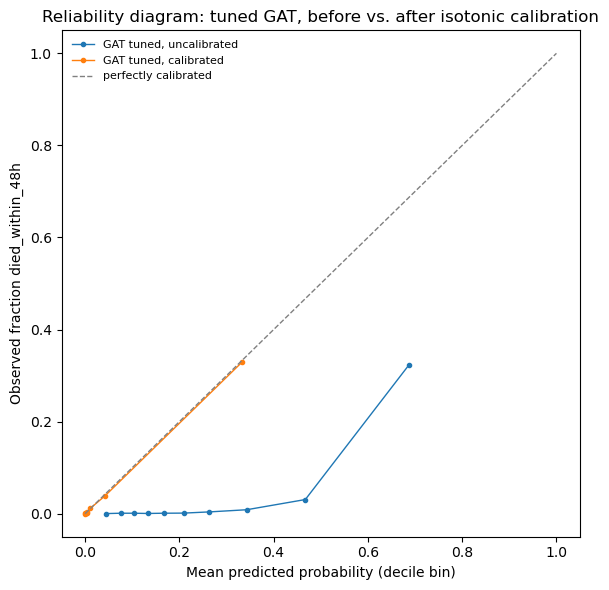

In [41]:
# ---- Refit the winning config once (final model, full epoch budget), then apply post-hoc
# isotonic calibration. Trains via train_gnn_fast (fast, partition-local subgraphs); test
# predictions come from the existing test-only subgraph built in the feature-importance
# section above (sub_edge_index/sub_edge_weight/X_test_enc_baseline), not from
# train_gnn_fast itself, since that function never touches test data at all.
tuned_result = train_gnn_fast(
    lambda: DoseGAT(
        in_channels=graph_data.x.shape[1],
        hidden_channels=best_cfg["hidden_channels"], heads=best_cfg["heads"], dropout=best_cfg["dropout"],
    ),
    "GAT (tuned)", use_edge_weight=True, seed=RANDOM_STATE, verbose=True,
    lr=best_cfg["lr"], weight_decay=best_cfg["weight_decay"],
    max_epochs=MAX_EPOCHS, patience=PATIENCE,
)
gat_tuned_model = tuned_result.model

gat_tuned_model.eval()
with torch.no_grad():
    gat_tuned_test_proba = torch.sigmoid(
        gat_tuned_model(torch.tensor(X_test_enc_baseline, dtype=torch.float32), sub_edge_index, sub_edge_weight)
    ).numpy()

gat_tuned_roc_auc = roc_auc_score(y_test_graph, gat_tuned_test_proba)
gat_tuned_pr_auc = average_precision_score(y_test_graph, gat_tuned_test_proba)
gat_tuned_brier_uncalibrated = brier_score_loss(y_test_graph, gat_tuned_test_proba)

print(
    f"Tuned GAT, uncalibrated -- ROC-AUC {gat_tuned_roc_auc:.3f}  PR-AUC {gat_tuned_pr_auc:.3f}  "
    f"Brier {gat_tuned_brier_uncalibrated:.4f}"
)

# Isotonic (not Platt/sigmoid) since the reliability diagram earlier showed the miscalibration
# isn't a simple systematic shift -- isotonic can fit that shape, a single sigmoid parameter
# can't. Fit on validation predictions only; applied to (never fit on) the test predictions.
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(tuned_result.val_proba, val_y)
gat_tuned_test_proba_calibrated = calibrator.predict(gat_tuned_test_proba)

# Isotonic regression is a monotonic (non-decreasing) transform, so it preserves rank order
# exactly -- ROC-AUC/PR-AUC should come out identical (up to tie-breaking) to the uncalibrated
# numbers above; only Brier score should change. If ROC-AUC/PR-AUC move meaningfully, something
# is wrong here.
gat_calibrated_roc_auc = roc_auc_score(y_test_graph, gat_tuned_test_proba_calibrated)
gat_calibrated_pr_auc = average_precision_score(y_test_graph, gat_tuned_test_proba_calibrated)
gat_calibrated_brier = brier_score_loss(y_test_graph, gat_tuned_test_proba_calibrated)

print(
    f"Tuned GAT, isotonic-calibrated -- ROC-AUC {gat_calibrated_roc_auc:.3f}  "
    f"PR-AUC {gat_calibrated_pr_auc:.3f}  Brier {gat_calibrated_brier:.4f} "
    f"(was {gat_tuned_brier_uncalibrated:.4f} uncalibrated)"
)

print("\n" + "=" * 70)
print("Final comparison: original single-seed GAT vs. tuned vs. tuned+calibrated vs. baselines")
print("=" * 70)
print(f"{'Model':<32}{'ROC-AUC':>10}{'PR-AUC':>10}{'Brier':>10}")
print(f"{'GAT (original hyperparameters)':<32}{gat_roc_auc:>10.3f}{gat_pr_auc:>10.3f}{brier_score_loss(y_test_graph, gat_test_proba):>10.4f}")
print(f"{'GAT (tuned, uncalibrated)':<32}{gat_tuned_roc_auc:>10.3f}{gat_tuned_pr_auc:>10.3f}{gat_tuned_brier_uncalibrated:>10.4f}")
print(f"{'GAT (tuned, calibrated)':<32}{gat_calibrated_roc_auc:>10.3f}{gat_calibrated_pr_auc:>10.3f}{gat_calibrated_brier:>10.4f}")
print(f"{'Untuned GBM':<32}{roc_auc_score(y_test, gbm_test_proba):>10.3f}{average_precision_score(y_test, gbm_test_proba):>10.3f}{brier_score_loss(y_test, gbm_test_proba):>10.4f}")
print(f"{'Tuned GBM (Intro.ipynb)':<32}{TUNED_GBM_ROC_AUC:>10.3f}{TUNED_GBM_PR_AUC:>10.3f}{'n/a':>10}")

# ---- Reliability diagram: tuned GAT before vs. after calibration ----
fig, ax = plt.subplots(figsize=(6, 6))
for label, proba in [
    ("GAT tuned, uncalibrated", gat_tuned_test_proba),
    ("GAT tuned, calibrated", gat_tuned_test_proba_calibrated),
]:
    frac_pos, mean_pred = calibration_curve(y_test_graph, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", markersize=3, linewidth=1, label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability (decile bin)")
ax.set_ylabel("Observed fraction died_within_48h")
ax.set_title("Reliability diagram: tuned GAT, before vs. after isotonic calibration")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Poster export figures




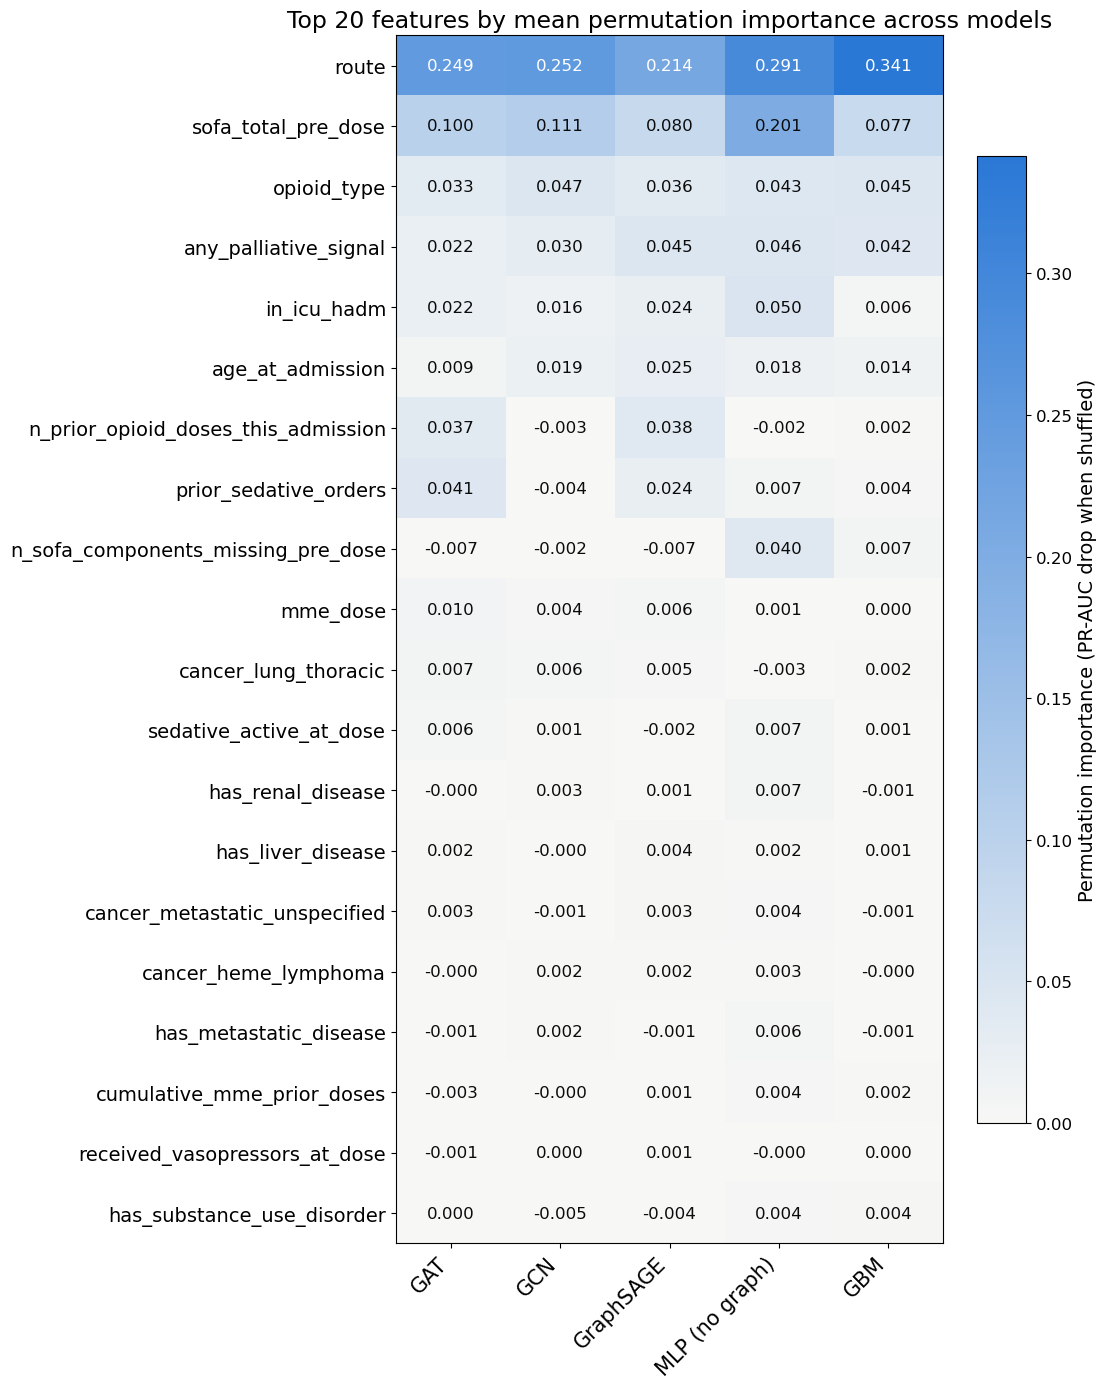

Saved poster figure to /alina-data1/emma-data/poster_figures


In [42]:
# ---- Poster-legible feature-importance heatmap: bigger fonts, high-res export ----
POSTER_FIG_DIR = "../poster_figures"
os.makedirs(POSTER_FIG_DIR, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 0.55 * top_n + 3))
im = ax.imshow(plot_df.to_numpy(), cmap=sequential_cmap, vmin=0, vmax=vmax, aspect="auto")

ax.set_xticks(range(len(plot_df.columns)))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right", fontsize=15)
ax.set_yticks(range(len(plot_df.index)))
ax.set_yticklabels(plot_df.index, fontsize=14)

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        v = plot_df.iat[i, j]
        text_color = "white" if v > vmax * 0.6 else "#0b0b0b"
        ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=12, color=text_color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Permutation importance (PR-AUC drop when shuffled)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.set_title(f"Top {top_n} features by mean permutation importance across models", fontsize=17)
plt.tight_layout()
fig.savefig(os.path.join(POSTER_FIG_DIR, "feature_importance_heatmap.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(POSTER_FIG_DIR, "feature_importance_heatmap.pdf"), bbox_inches="tight")
plt.show()
print(f"Saved poster figure to {os.path.abspath(POSTER_FIG_DIR)}")


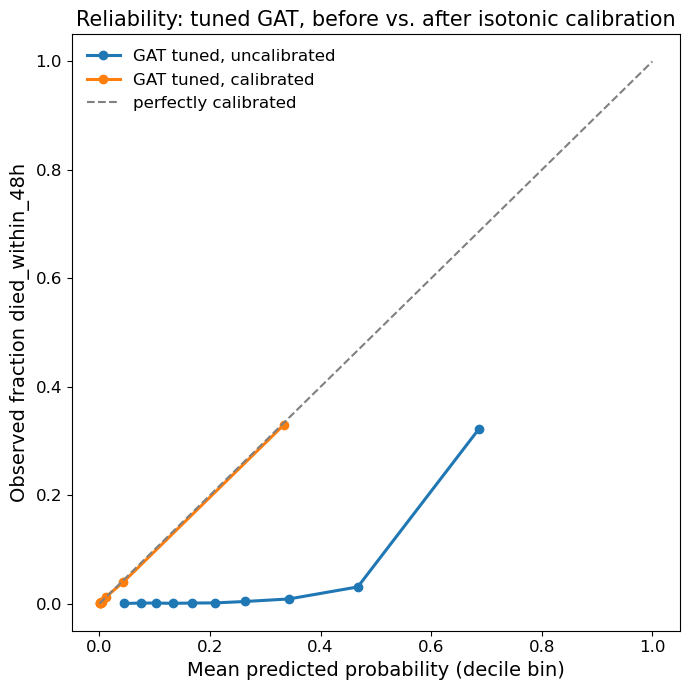

Saved poster figure to /alina-data1/emma-data/poster_figures


In [43]:
# ---- Poster-legible reliability diagram: tuned GAT before vs. after calibration ----
fig, ax = plt.subplots(figsize=(7, 7))
for label, proba in [
    ("GAT tuned, uncalibrated", gat_tuned_test_proba),
    ("GAT tuned, calibrated", gat_tuned_test_proba_calibrated),
]:
    frac_pos, mean_pred = calibration_curve(y_test_graph, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", markersize=6, linewidth=2.2, label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5, label="perfectly calibrated")
ax.set_xlabel("Mean predicted probability (decile bin)", fontsize=14)
ax.set_ylabel("Observed fraction died_within_48h", fontsize=14)
ax.set_title("Reliability: tuned GAT, before vs. after isotonic calibration", fontsize=15)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
fig.savefig(os.path.join(POSTER_FIG_DIR, "gat_calibration.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(POSTER_FIG_DIR, "gat_calibration.pdf"), bbox_inches="tight")
plt.show()
print(f"Saved poster figure to {os.path.abspath(POSTER_FIG_DIR)}")


### Dose-response curve

Descriptive, not causal: sicker patients tend to receive larger doses, so a raw dose-mortality
relationship is confounded by severity in the direction that would make higher doses look more
dangerous than they are (or mask the reverse). This is exactly the confound `sofa_total_pre_dose`
in the models above is meant to net out -- read this curve as motivation for that adjustment, not
as an adjusted estimate itself.


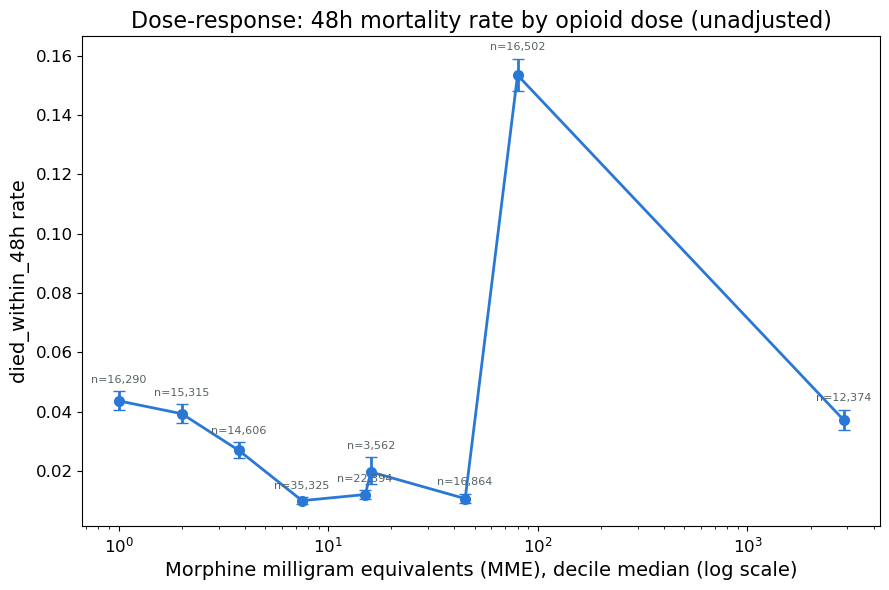

         mme_bin  n_doses  n_deaths  median_mme     rate   ci_low  ci_high
   (-0.001, 1.5]    16290       711        1.00 0.043646 0.040615 0.046893
      (1.5, 2.0]    15315       602        2.00 0.039308 0.036344 0.042503
      (2.0, 4.0]    14606       393        3.75 0.026907 0.024404 0.029658
      (4.0, 7.5]    35325       353        7.50 0.009993 0.009008 0.011085
     (7.5, 15.0]    22394       270       15.00 0.012057 0.010709 0.013572
    (15.0, 22.5]     3562        70       16.00 0.019652 0.015584 0.024755
    (22.5, 60.0]    16864       180       45.00 0.010674 0.009230 0.012340
   (60.0, 100.0]    16502      2533       80.00 0.153497 0.148077 0.159077
(100.0, 30000.0]    12374       460     2880.00 0.037175 0.033982 0.040654
Saved poster figure to /alina-data1/emma-data/poster_figures


In [44]:
# ---- Dose-response curve: 48h mortality rate by opioid dose (MME), deciled ----
dose_resp = dose_df.dropna(subset=["mme_dose", "died_within_48h"]).copy()
dose_resp["mme_bin"] = pd.qcut(dose_resp["mme_dose"], q=10, duplicates="drop")

def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half_width = (z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (center - half_width, center + half_width)

bin_stats = (
    dose_resp.groupby("mme_bin", observed=True)
    .agg(n_doses=("died_within_48h", "size"),
         n_deaths=("died_within_48h", "sum"),
         median_mme=("mme_dose", "median"))
    .reset_index()
)
bin_stats["rate"] = bin_stats["n_deaths"] / bin_stats["n_doses"]
ci_bounds = bin_stats.apply(lambda r: wilson_ci(r["n_deaths"], r["n_doses"]), axis=1)
bin_stats["ci_low"] = [c[0] for c in ci_bounds]
bin_stats["ci_high"] = [c[1] for c in ci_bounds]

fig, ax = plt.subplots(figsize=(9, 6))
yerr = np.vstack([
    (bin_stats["rate"] - bin_stats["ci_low"]).clip(lower=0),
    (bin_stats["ci_high"] - bin_stats["rate"]).clip(lower=0),
])
ax.errorbar(bin_stats["median_mme"], bin_stats["rate"], yerr=yerr,
            marker="o", markersize=7, linewidth=2, capsize=4, color="#2a78d6")
ax.set_xscale("log")
ax.set_xlabel("Morphine milligram equivalents (MME), decile median (log scale)", fontsize=14)
ax.set_ylabel("died_within_48h rate", fontsize=14)
ax.set_title("Dose-response: 48h mortality rate by opioid dose (unadjusted)", fontsize=16)
ax.tick_params(labelsize=12)
for _, r in bin_stats.iterrows():
    ax.annotate(f"n={r['n_doses']:,}", (r["median_mme"], r["ci_high"]),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8, color="#55625f")
plt.tight_layout()
fig.savefig(os.path.join(POSTER_FIG_DIR, "dose_response_curve.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(POSTER_FIG_DIR, "dose_response_curve.pdf"), bbox_inches="tight")
plt.show()
print(bin_stats.to_string(index=False))
print(f"Saved poster figure to {os.path.abspath(POSTER_FIG_DIR)}")


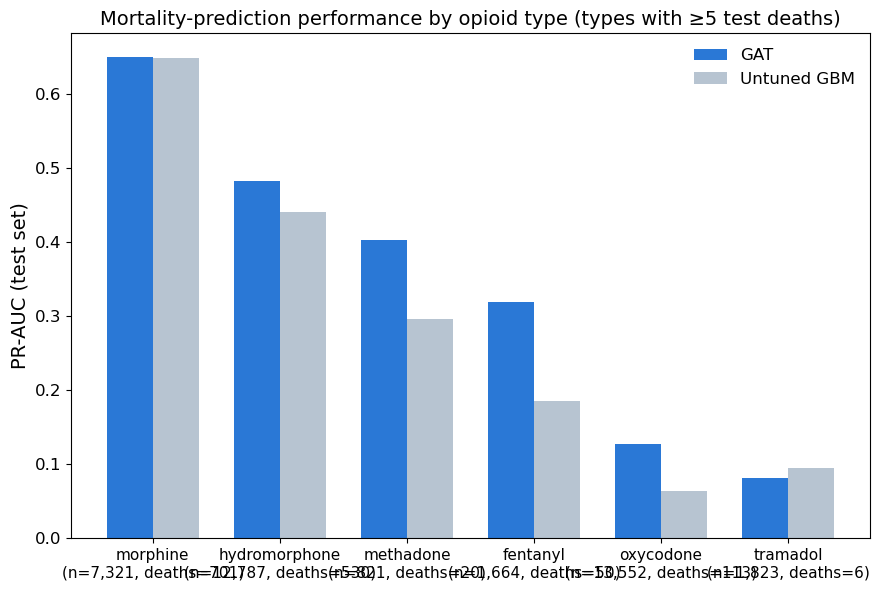

  opioid_type  n_doses  n_deaths      GAT      GBM
     morphine     7321       701 0.649983 0.648971
hydromorphone    12787       530 0.482549 0.440610
    methadone      821        20 0.402850 0.296623
     fentanyl     1664        50 0.319028 0.185332
    oxycodone    13552       113 0.127191 0.063553
     tramadol     1823         6 0.080456 0.095038
Saved poster figure to /alina-data1/emma-data/poster_figures


In [45]:
# ---- Per-opioid_type bar chart (recomputes the breakdown above into plottable form) ----
type_rows = []
for opioid in sorted(dose_df["opioid_type"].dropna().unique()):
    gnn_sub = opioid_type_gnn_order == opioid
    gbm_sub = opioid_type_gbm_order == opioid
    n_doses = int(gnn_sub.sum())
    n_deaths = int(y_test_graph[gnn_sub].sum())
    if n_deaths < MIN_SUBGROUP_DEATHS:
        continue
    gat_pr_sub = average_precision_score(y_test_graph[gnn_sub], gat_test_proba[gnn_sub])
    gbm_pr_sub = average_precision_score(y_test.to_numpy()[gbm_sub], gbm_test_proba[gbm_sub])
    type_rows.append({"opioid_type": opioid, "n_doses": n_doses, "n_deaths": n_deaths,
                       "GAT": gat_pr_sub, "GBM": gbm_pr_sub})

type_df = pd.DataFrame(type_rows).sort_values("GAT", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(type_df))
width = 0.36
ax.bar(x - width / 2, type_df["GAT"], width, label="GAT", color="#2a78d6")
ax.bar(x + width / 2, type_df["GBM"], width, label="Untuned GBM", color="#b7c4d1")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{t}\n(n={n:,}, deaths={d})" for t, n, d in zip(type_df["opioid_type"], type_df["n_doses"], type_df["n_deaths"])],
    fontsize=11,
)
ax.set_ylabel("PR-AUC (test set)", fontsize=14)
ax.set_title(f"Mortality-prediction performance by opioid type (types with \u2265{MIN_SUBGROUP_DEATHS} test deaths)", fontsize=14)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=12, frameon=False)
plt.tight_layout()
fig.savefig(os.path.join(POSTER_FIG_DIR, "opioid_type_breakdown.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(POSTER_FIG_DIR, "opioid_type_breakdown.pdf"), bbox_inches="tight")
plt.show()
print(type_df.to_string(index=False))
print(f"Saved poster figure to {os.path.abspath(POSTER_FIG_DIR)}")


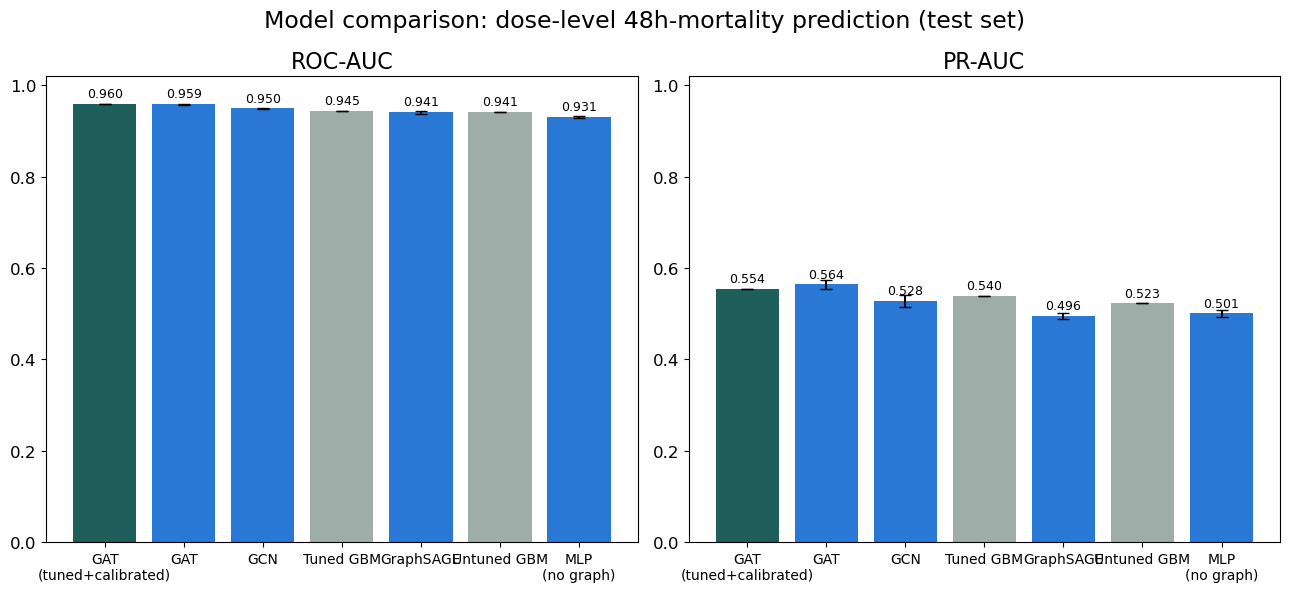

Saved poster figure to /alina-data1/emma-data/poster_figures


In [46]:
# ---- Model comparison bar chart: ROC-AUC & PR-AUC, 5-seed mean +/- std where applicable ----
model_labels = ["GAT\n(tuned+calibrated)", "GAT", "GCN", "Tuned GBM", "GraphSAGE", "Untuned GBM", "MLP\n(no graph)"]
roc_vals = [gat_calibrated_roc_auc, summary.loc["GAT", "roc_auc_mean"], summary.loc["GCN", "roc_auc_mean"],
            TUNED_GBM_ROC_AUC, summary.loc["GraphSAGE", "roc_auc_mean"], gbm_roc, summary.loc["MLP (no graph)", "roc_auc_mean"]]
roc_err = [0, summary.loc["GAT", "roc_auc_std"], summary.loc["GCN", "roc_auc_std"],
           0, summary.loc["GraphSAGE", "roc_auc_std"], 0, summary.loc["MLP (no graph)", "roc_auc_std"]]
pr_vals = [gat_calibrated_pr_auc, summary.loc["GAT", "pr_auc_mean"], summary.loc["GCN", "pr_auc_mean"],
           TUNED_GBM_PR_AUC, summary.loc["GraphSAGE", "pr_auc_mean"], gbm_pr, summary.loc["MLP (no graph)", "pr_auc_mean"]]
pr_err = [0, summary.loc["GAT", "pr_auc_std"], summary.loc["GCN", "pr_auc_std"],
          0, summary.loc["GraphSAGE", "pr_auc_std"], 0, summary.loc["MLP (no graph)", "pr_auc_std"]]

colors = ["#1f5f5b" if "tuned+calibrated" in m else ("#9fada9" if "GBM" in m else "#2a78d6") for m in model_labels]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, vals, err, title in [(axes[0], roc_vals, roc_err, "ROC-AUC"), (axes[1], pr_vals, pr_err, "PR-AUC")]:
    x = np.arange(len(model_labels))
    ax.bar(x, vals, yerr=err, capsize=4, color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=10)
    ax.set_ylim(0, 1.02)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="y", labelsize=12)
    for xi, v in zip(x, vals):
        ax.text(xi, v + 0.015, f"{v:.3f}", ha="center", fontsize=9)

fig.suptitle("Model comparison: dose-level 48h-mortality prediction (test set)", fontsize=17)
plt.tight_layout()
fig.savefig(os.path.join(POSTER_FIG_DIR, "model_comparison.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(POSTER_FIG_DIR, "model_comparison.pdf"), bbox_inches="tight")
plt.show()
print(f"Saved poster figure to {os.path.abspath(POSTER_FIG_DIR)}")
